# Testing the decided defaults: finding small/large-n and small/large-distinct cutoffs

**Decided defaults being tested:**

| Data configuration | Small n default | Small n alternatives | Large n default | Large n alternatives |
|---|---|---|---|---|
| 1D discrete-ish | Dot plot | Impulse, Bar, density, ecdf, rug | Impulse | Histogram (many distinct values), Density + Rug |
| 1D continuous-ish | Strip plot | Impulse, Rug, Boxplot (overlay?), (density, rug) | Histogram | Density (overlay?), Boxplot (overlay?), rug |
| 2D discrete x discrete | Scatter with Jitter | Tile, Scatter with Size | Tile/Heatmap | Scatter, Mosaic, Marginal dists (overlay) |
| 2D continuous x continuous | Scatter | Density | Density | Contour, Marginal dists (overlay) |
| 2D discrete x continuous | Scatter (segmented strip plot) | Box Plot/Violin Plot | Violin/Box + Density | Scatter, Marginal dists (overlay) |
| 2D continuous x discrete | Scatter (segmented strip plot) | Box/violin | Violin/Box + Density | Scatter, Marginal dists (overlay) |
| Process time point, discrete-valued | Dot Plot | Impulse | Impulse | Histogram |
| Process time point, continuous-valued | Strip plot | -- | Histogram | Density (overlay?), Boxplot (overlay?), rug |
| 1D categorical/string | Dot plot | Impulse, Bar | Impulse | Histogram (many distinct values), Density + Rug |

**What each section below does:** one representative distribution per category,
swept across `n` (small n default vs. large n default side by side) to find
where the crossover should be, and -- for categories where the number of
distinct values matters (discrete-ish and categorical) -- a second sweep across
the number of distinct values at a fixed large `n`, to find `n_unique_threshold`.

**Overlay variants** (stacked dot plots + color, side-by-side heatmaps, etc.)
are shown at the end as single small-n/large-n mockups for visual reference --
they're a group-comparison technique, not really an "n cutoff" question, so
they aren't swept the same way.


In [48]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from symbulate import *
from scipy.stats import gaussian_kde
from scipy.spatial import cKDTree

%matplotlib inline
plt.rcParams['figure.max_open_warning'] = 200


## Helper functions

Custom implementations for defaults that don't exist as a `type=` in symbulate today.

In [49]:
def get_counts(values):
    d = {}
    for v in values:
        d[v] = d.get(v, 0) + 1
    return dict(sorted(d.items()))

def kde_curve(values, n=200):
    values = np.asarray(values, dtype=float)
    density = gaussian_kde(values)
    xs = np.linspace(values.min(), values.max(), n)
    return xs, density(xs)

def nn_overplot_score(x, y):
    """Mean nearest-neighbor distance normalized by spatial extent -- smaller = more overplotted."""
    pts = np.column_stack([x, y])
    tree = cKDTree(pts)
    d, _ = tree.query(pts, k=2)
    scale = max(x.max() - x.min(), y.max() - y.min())
    return float(np.mean(d[:, 1]) / scale) if scale > 0 else float('nan')


def dot_plot(ax, values, title=None):
    """[CUSTOM] Wilkinson dot plot -- one dot per observation, stacked at each distinct value."""
    counts = get_counts(values)
    for x, c in counts.items():
        ax.scatter([x] * c, range(1, c + 1), color='steelblue', edgecolor='black',
                   zorder=3, s=25)
    ax.set_yticks([])
    ax.set_ylim(0, max(counts.values()) + 1)
    if title:
        ax.set_title(title)


def strip_plot(ax, values, y_jitter=0.15, title=None):
    """[CUSTOM] 1D strip plot -- points at a fixed y with small vertical jitter."""
    values = np.asarray(values)
    y = np.random.uniform(-y_jitter, y_jitter, size=len(values))
    ax.scatter(values, y, alpha=0.4, color='steelblue', edgecolor='none', s=15)
    ax.set_yticks([])
    ax.set_ylim(-1, 1)
    if title:
        ax.set_title(title)


def violin_plus_density(ax, group_values_by_position, vert=True, title=None):
    """[CUSTOM] Grouped violin plot with a KDE curve overlaid on each violin."""
    positions = sorted(group_values_by_position.keys())
    groups = [group_values_by_position[p] for p in positions]
    ax.violinplot(groups, positions=positions, showmedians=True, vert=vert)
    for pos, g in zip(positions, groups):
        if len(set(g)) < 2:
            continue
        xs_k, dens_k = kde_curve(g)
        dens_k = dens_k / dens_k.max() * 0.4
        if vert:
            ax.plot(pos + dens_k, xs_k, color='crimson', linewidth=1.5)
        else:
            ax.plot(xs_k, pos + dens_k, color='crimson', linewidth=1.5)
    if title:
        ax.set_title(title)


def bubble_grid(ax, x, y, title=None):
    """[CUSTOM] 'Scatter with Size' -- point size encodes joint relative frequency."""
    counts = get_counts(list(zip(x, y)))
    xs = [k[0] for k in counts.keys()]
    ys = [k[1] for k in counts.keys()]
    sizes = [v / len(x) for v in counts.values()]
    ax.scatter(xs, ys, s=[s * 4000 for s in sizes], alpha=0.7, edgecolor='black')
    if title:
        ax.set_title(title)


def categorical_dot_plot(ax, labels, title=None):
    """[CUSTOM] Dot plot for string/categorical data (bypasses RV entirely)."""
    counts = get_counts(labels)
    cats = list(counts.keys())
    for i, (lab, c) in enumerate(counts.items()):
        ax.scatter([i] * c, range(1, c + 1), color='steelblue', edgecolor='black', zorder=3, s=25)
    ax.set_xticks(range(len(cats)))
    ax.set_xticklabels(cats, rotation=45 if len(cats) > 8 else 0, ha='right' if len(cats) > 8 else 'center')
    ax.set_yticks([])
    if title:
        ax.set_title(title)


def categorical_impulse_plot(ax, labels, title=None):
    """[CUSTOM] Impulse/spike plot for string/categorical data (bypasses RV entirely)."""
    counts = get_counts(labels)
    cats = list(counts.keys())
    heights = [v / len(labels) for v in counts.values()]
    ax.vlines(range(len(cats)), 0, heights, color='steelblue', linewidth=3)
    ax.set_xticks(range(len(cats)))
    ax.set_xticklabels(cats, rotation=45 if len(cats) > 8 else 0, ha='right' if len(cats) > 8 else 'center')
    ax.set_ylabel("Relative frequency")
    if title:
        ax.set_title(title)


---
## 1. 1D discrete-ish -- `RV(Binomial(5, 0.3))`

Small n default: **Dot plot** [CUSTOM]. Large n default: **Impulse** (native `type='impulse'`).

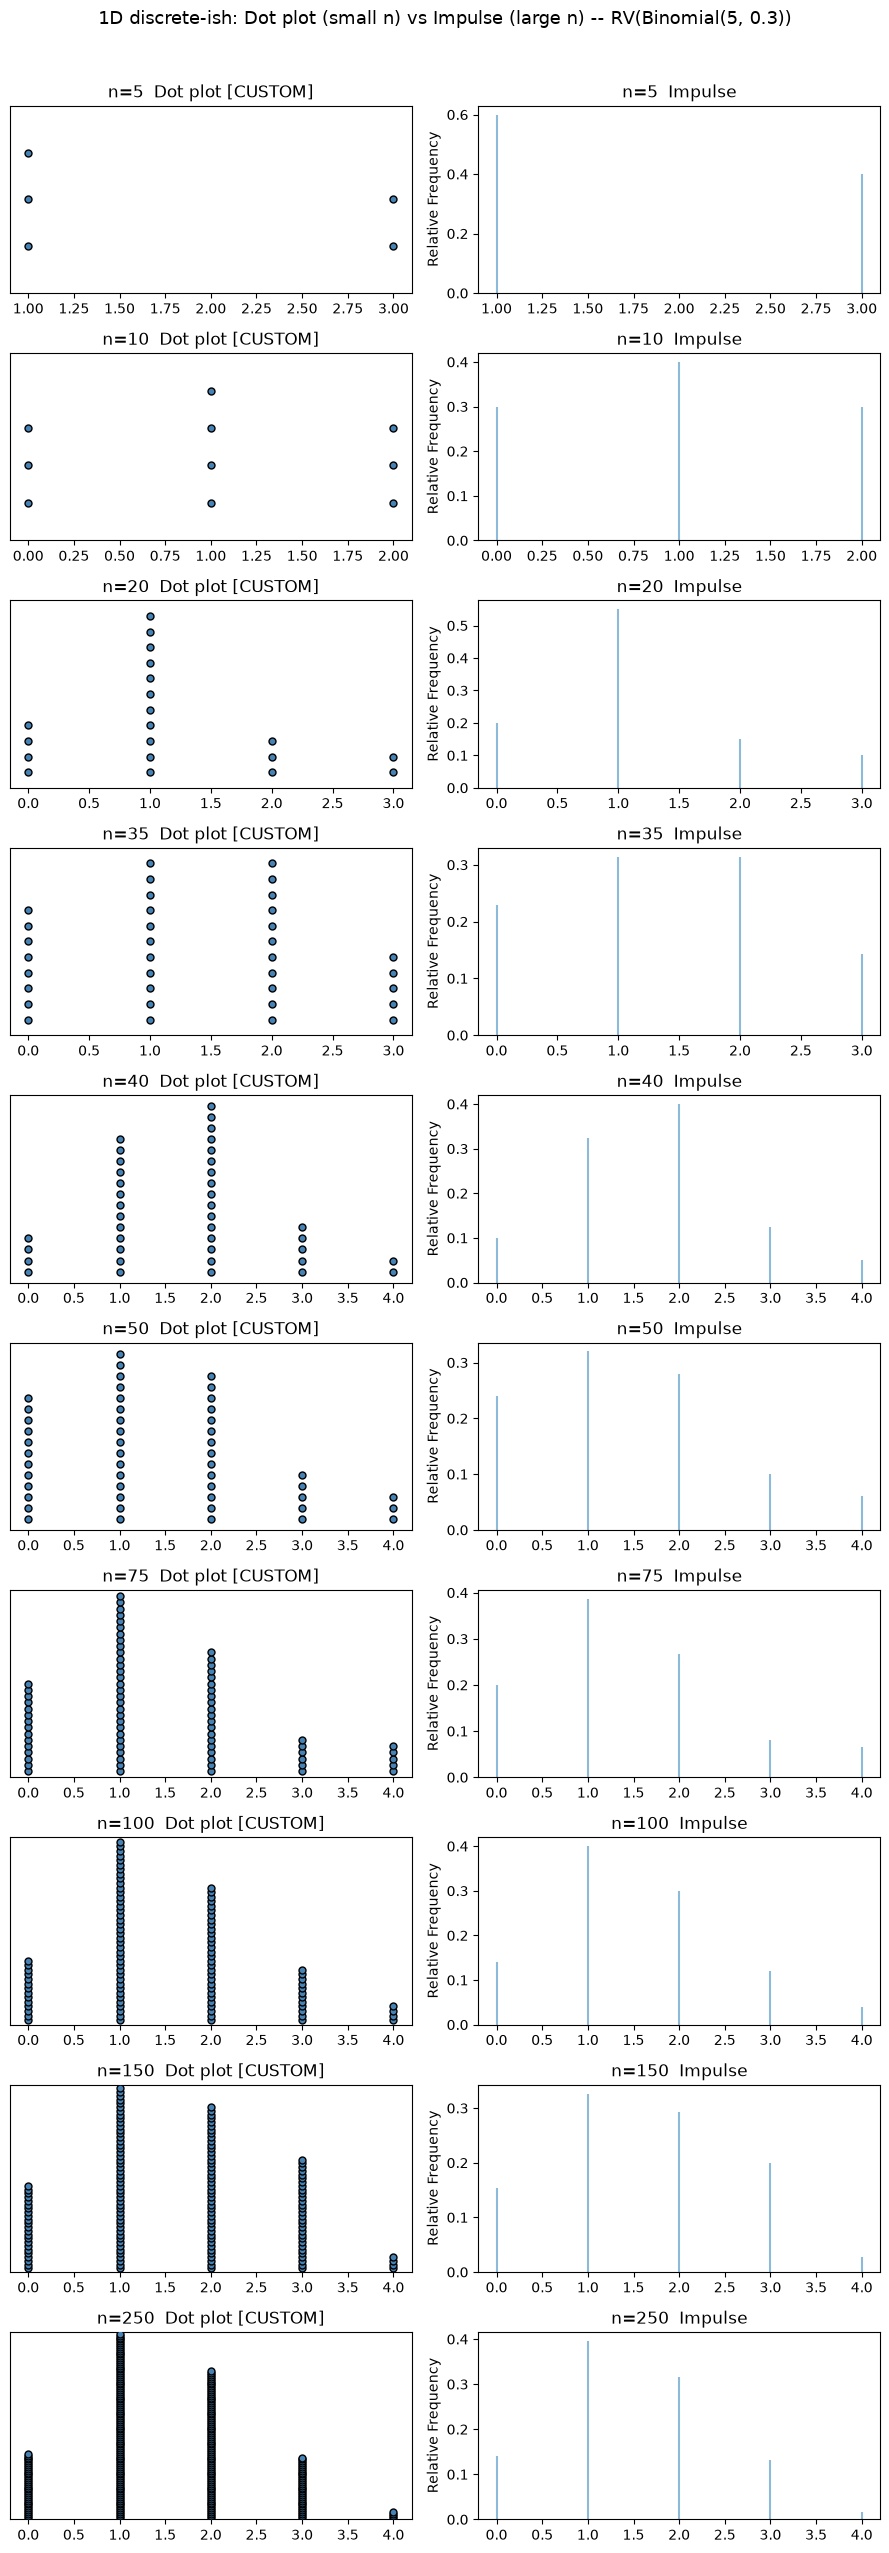

In [50]:
N_SWEEP = [5, 10, 20, 35, 40, 50,
           75, 100, 150, 250]

fig, axes = plt.subplots(len(N_SWEEP), 2, figsize=(9, 2.6 * len(N_SWEEP)))
for i, n in enumerate(N_SWEEP):
    sim = RV(Binomial(5, 0.3)).sim(n)
    sim._set_array()
    dot_plot(axes[i, 0], sim.array, title=f"n={n}  Dot plot [CUSTOM]")
    plt.sca(axes[i, 1])
    sim.plot(type='impulse')
    axes[i, 1].set_title(f"n={n}  Impulse")
fig.suptitle("1D discrete-ish: Dot plot (small n) vs Impulse (large n) -- RV(Binomial(5, 0.3))", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

**Distinct-value sweep** (n_unique_threshold), fixed large n=3000, `RV(DiscreteUniform(1, k))`
-- worst case (flat distribution, no natural peak):

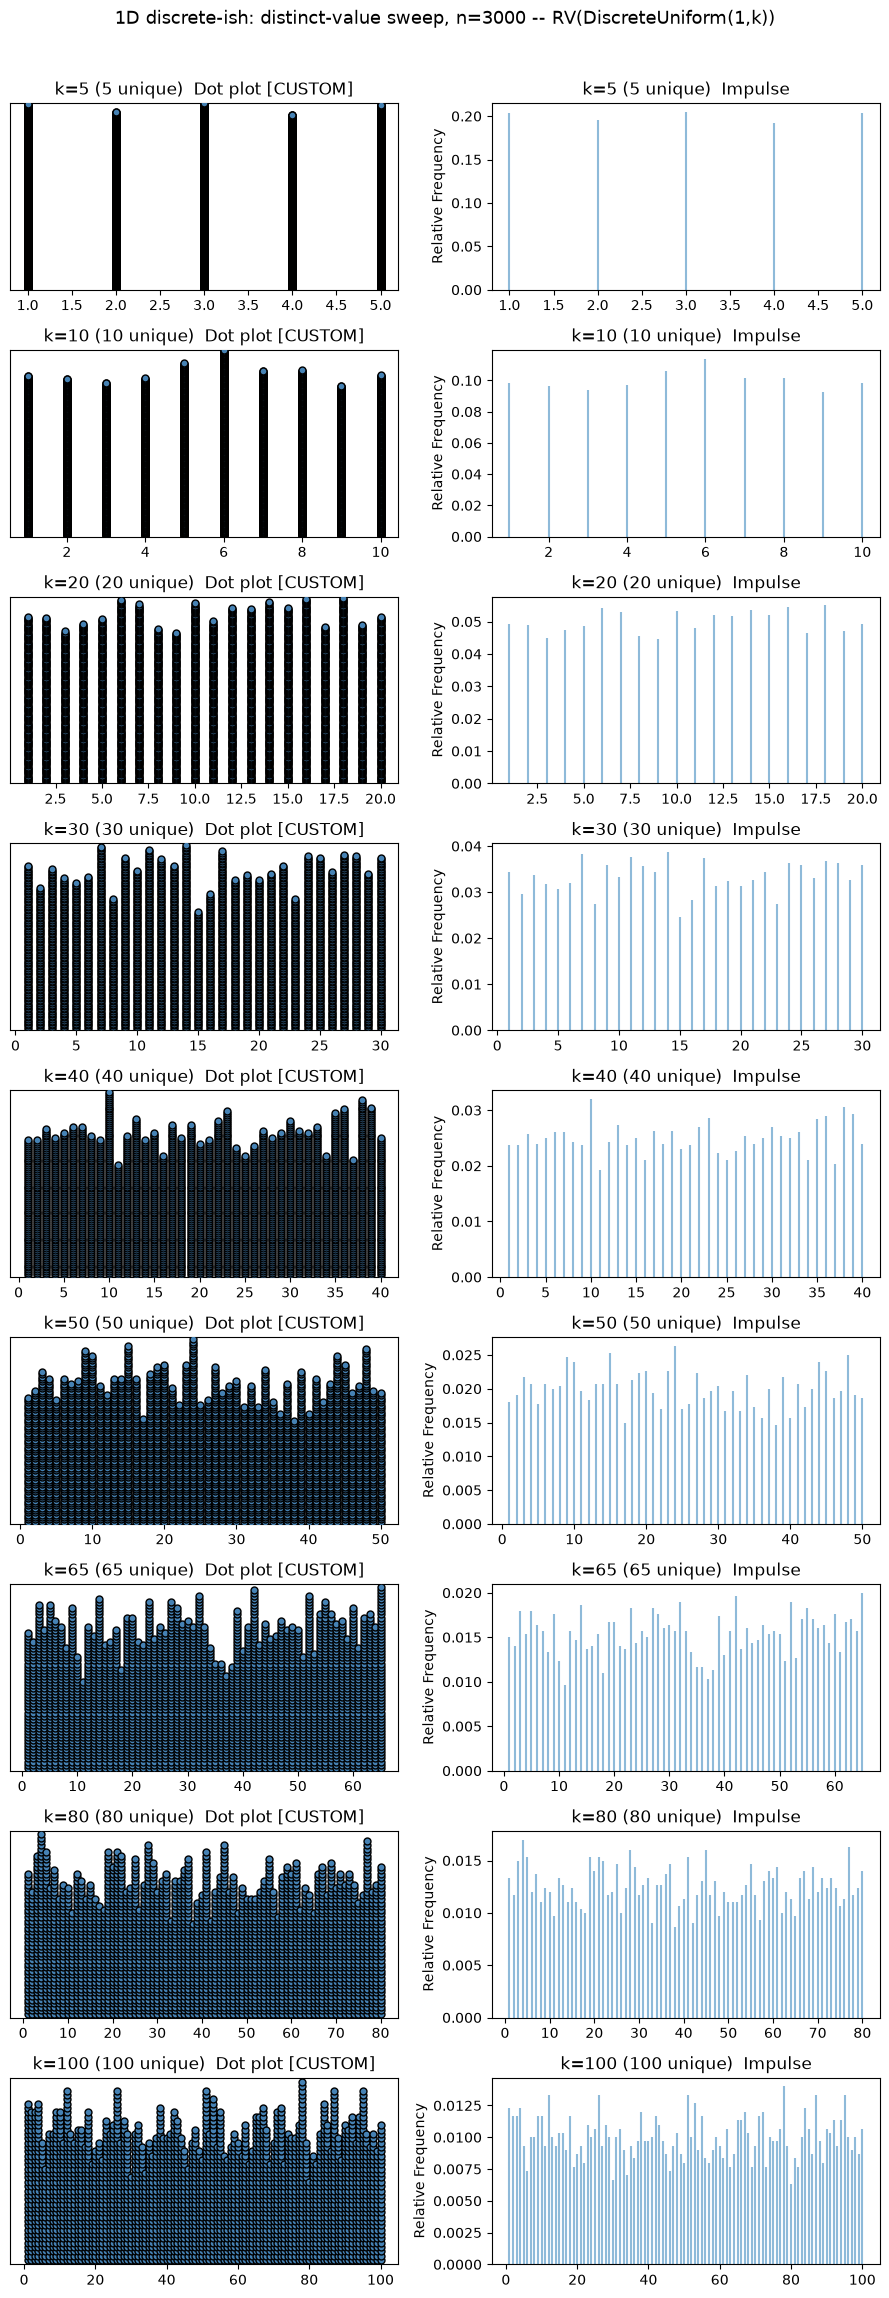

In [51]:
K_SWEEP = [5, 10, 20, 30, 40, 50, 65, 80, 100]

fig, axes = plt.subplots(len(K_SWEEP), 2, figsize=(9, 2.6 * len(K_SWEEP)))
for i, k in enumerate(K_SWEEP):
    sim = RV(DiscreteUniform(1, k)).sim(3000)
    sim._set_array()
    n_unique = len(set(sim.array.tolist()))
    dot_plot(axes[i, 0], sim.array, title=f"k={k} ({n_unique} unique)  Dot plot [CUSTOM]")
    plt.sca(axes[i, 1])
    sim.plot(type='impulse')
    axes[i, 1].set_title(f"k={k} ({n_unique} unique)  Impulse")
fig.suptitle("1D discrete-ish: distinct-value sweep, n=3000 -- RV(DiscreteUniform(1,k))", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

**Corner case**: small n but many possible distinct values --
`RV(DiscreteUniform(1, 100)).sim(15)`. With so few draws relative to the support,
almost every draw is likely to be unique regardless of `n_unique_threshold`.

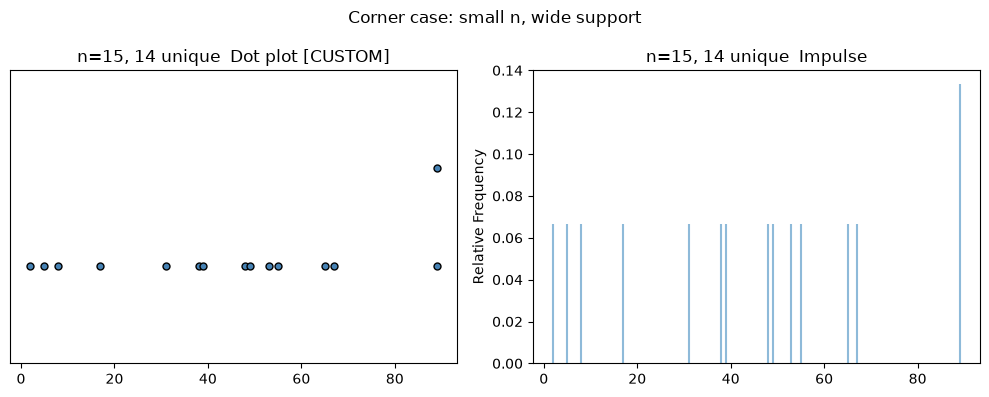

In [52]:
sim = RV(DiscreteUniform(1, 100)).sim(15)
sim._set_array()
n_unique = len(set(sim.array.tolist()))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
dot_plot(axes[0], sim.array, title=f"n=15, {n_unique} unique  Dot plot [CUSTOM]")
plt.sca(axes[1])
sim.plot(type='impulse')
axes[1].set_title(f"n=15, {n_unique} unique  Impulse")
fig.suptitle("Corner case: small n, wide support")
fig.tight_layout()
plt.show()

_Notes -- 1D discrete-ish crossover n, and n_unique_threshold:_

- Crossover n (dot plot -> impulse):
- n_unique_threshold (impulse -> treat as continuous-ish):


---
## 2. 1D continuous-ish -- `RV(Normal())`

Small n default: **Strip plot** [CUSTOM]. Large n default: **Histogram** (native `type='hist'`).

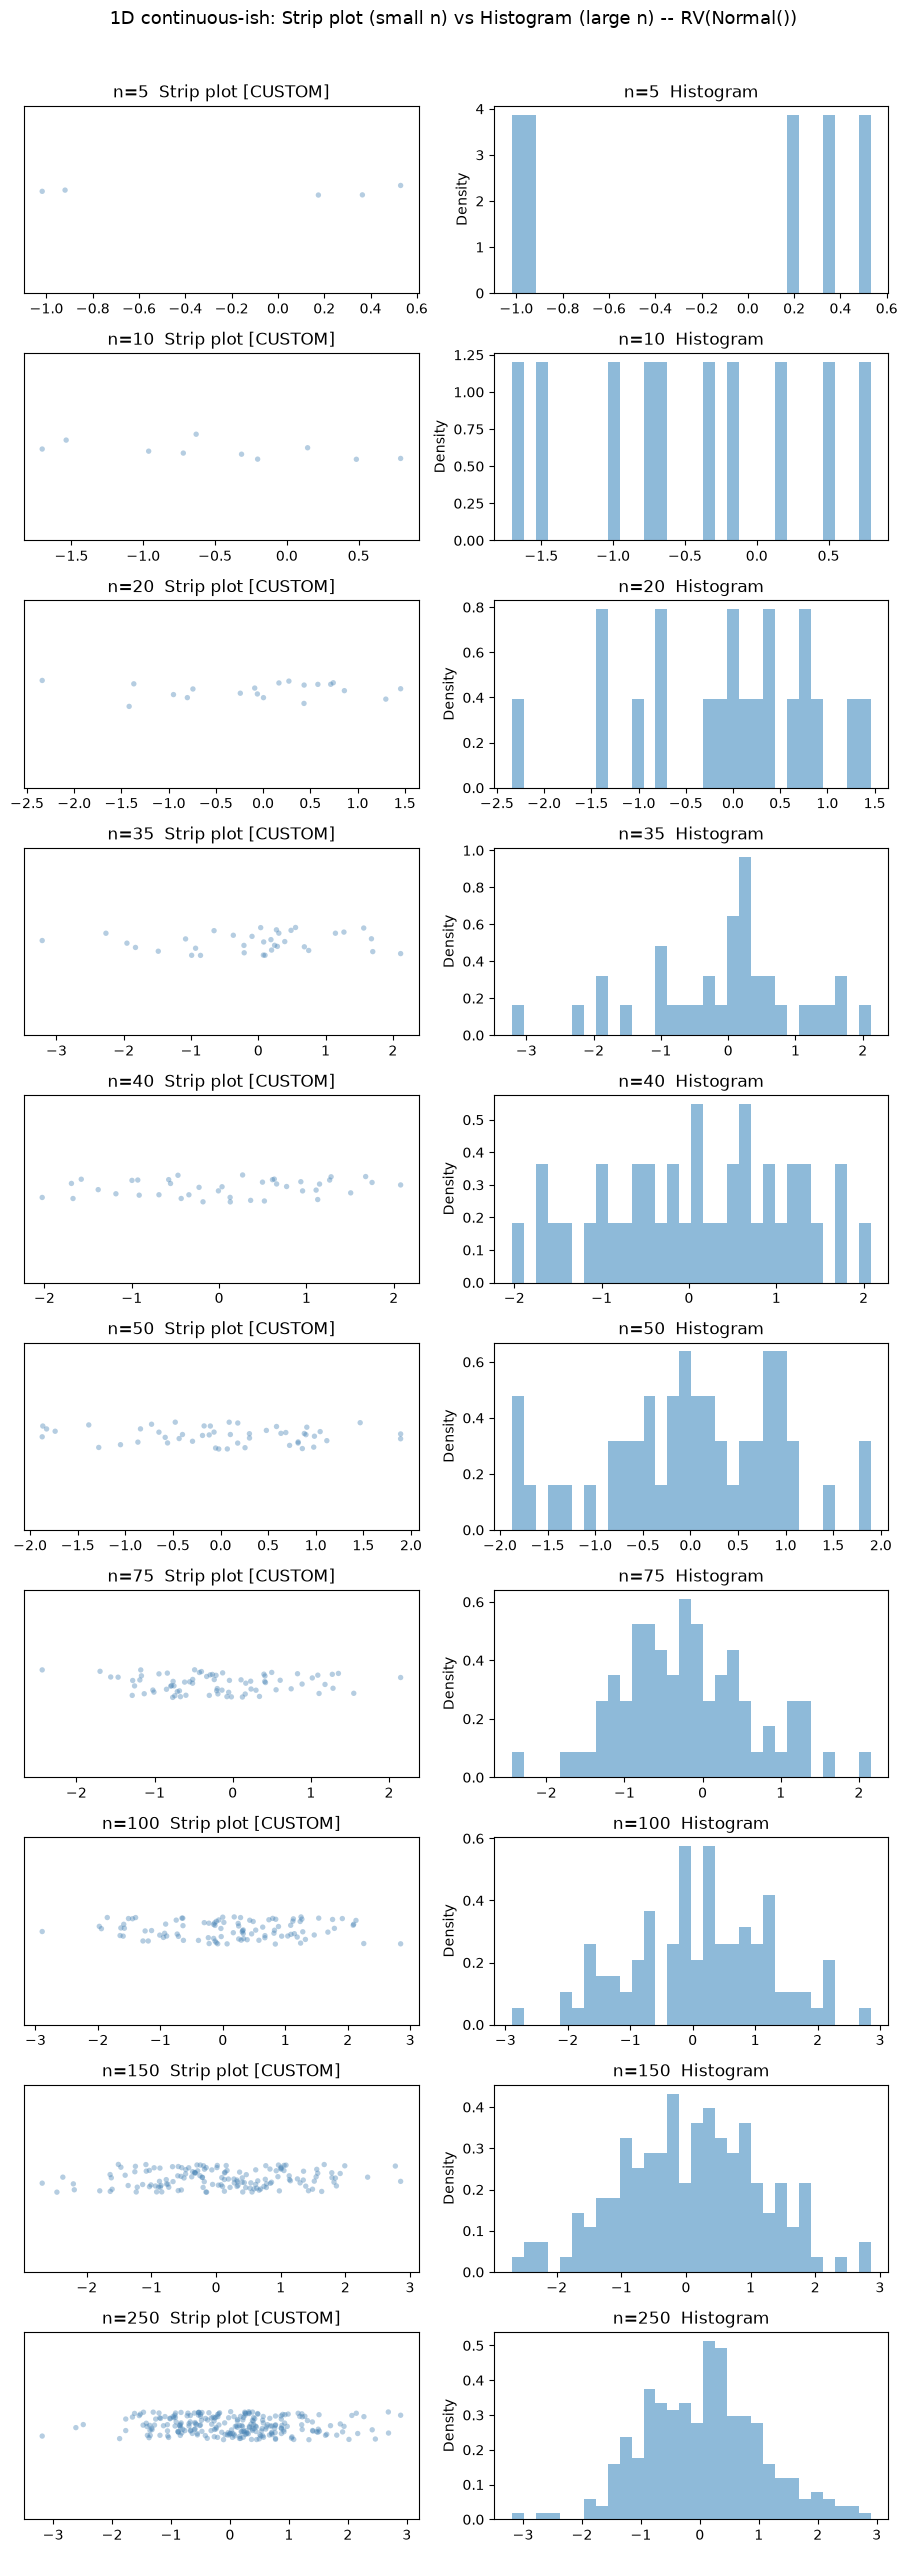

In [53]:
fig, axes = plt.subplots(len(N_SWEEP), 2, figsize=(9, 2.6 * len(N_SWEEP)))
for i, n in enumerate(N_SWEEP):
    sim = RV(Normal()).sim(n)
    sim._set_array()
    strip_plot(axes[i, 0], sim.array, title=f"n={n}  Strip plot [CUSTOM]")
    plt.sca(axes[i, 1])
    sim.plot(type='hist')
    axes[i, 1].set_title(f"n={n}  Histogram")
fig.suptitle("1D continuous-ish: Strip plot (small n) vs Histogram (large n) -- RV(Normal())", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

_Notes -- 1D continuous-ish crossover n:_

- 

---
## 3. 2D discrete x discrete -- `RV(Binomial(5, 0.3) * Binomial(5, 0.3))`

Small n default: **Scatter with Jitter** (native `type='scatter', jitter=True`).
Large n default: **Tile/Heatmap** (native `type='tile'`). Each `n` also prints
the most-crowded (x, y) cell's share of the total -- a direct read on how badly
plain jitter is failing to separate overlapping points.

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\3968560023.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


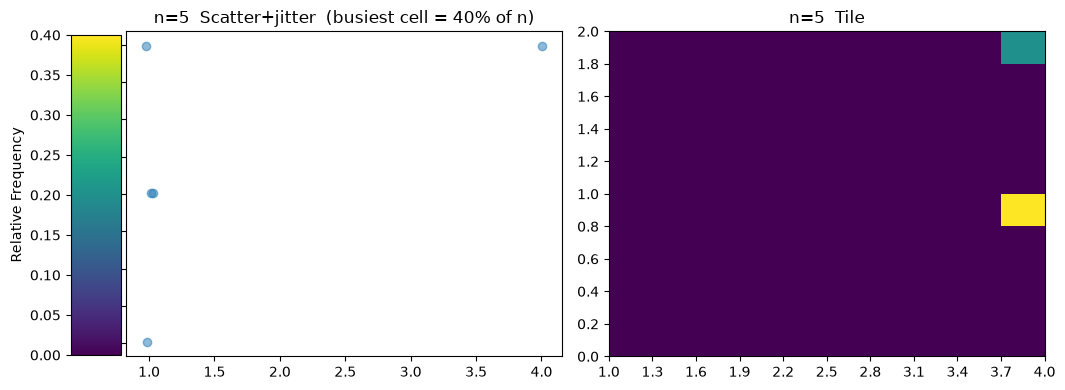

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\3968560023.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


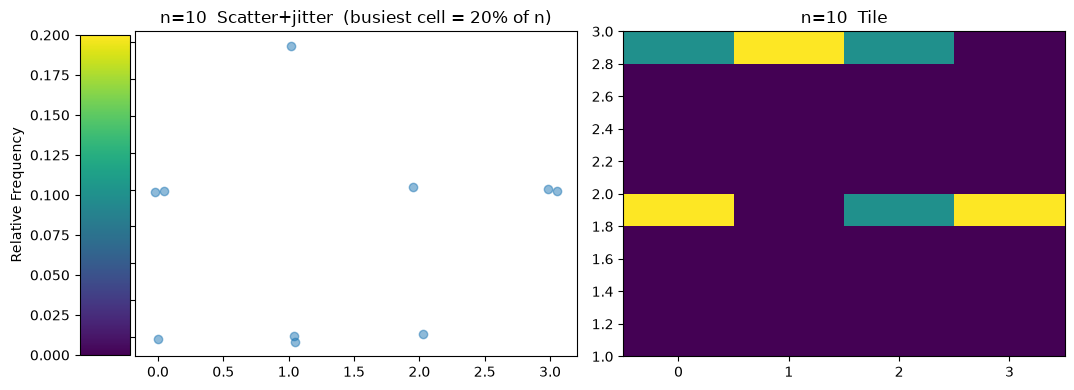

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\3968560023.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


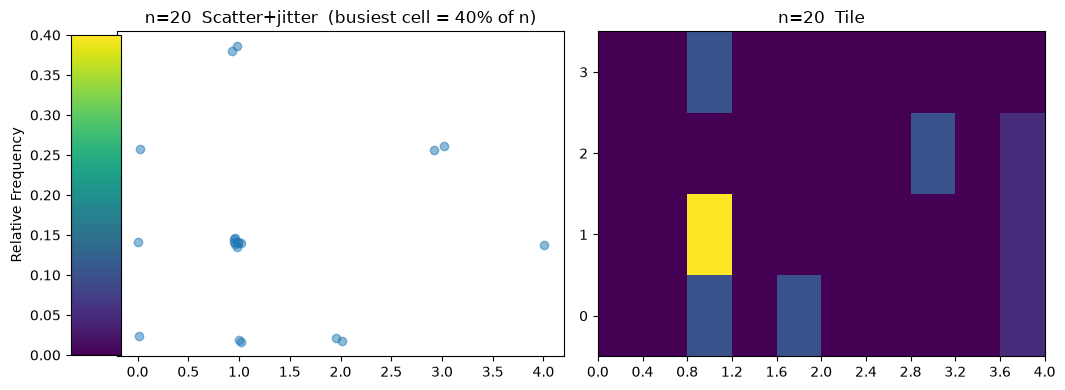

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\3968560023.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


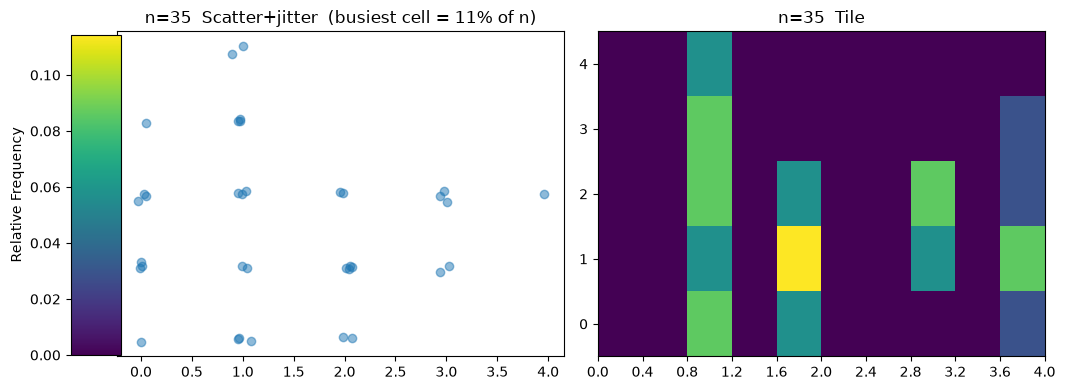

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\3968560023.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


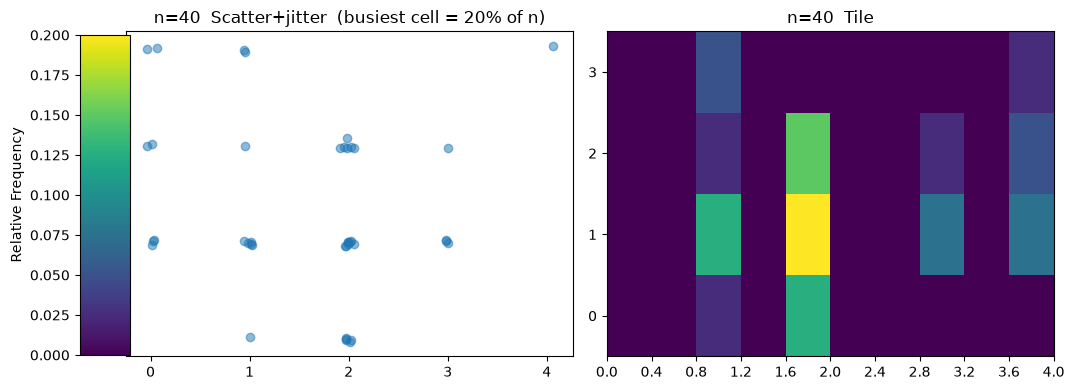

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\3968560023.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


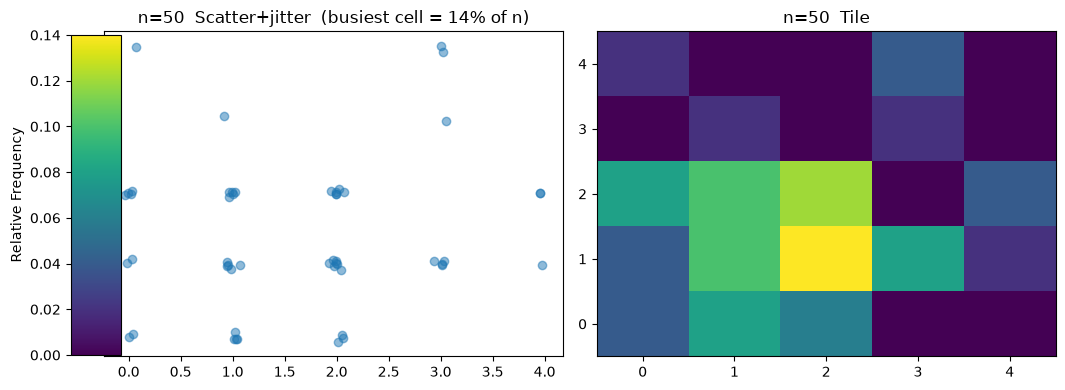

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\3968560023.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


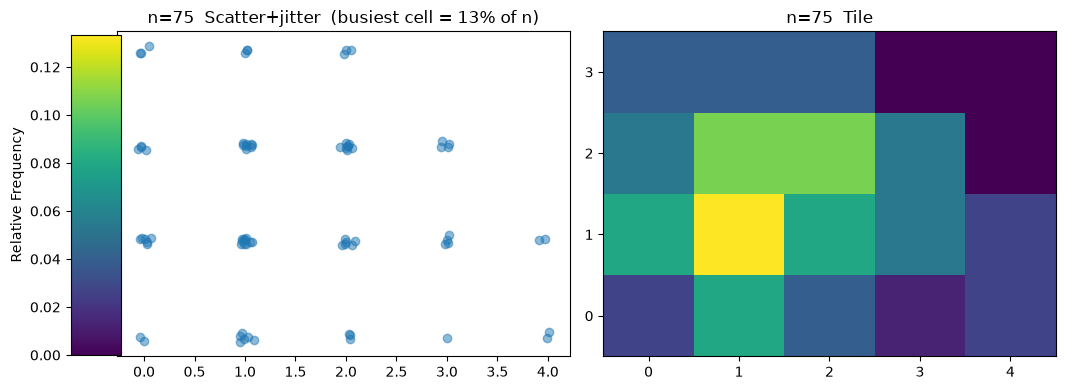

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\3968560023.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


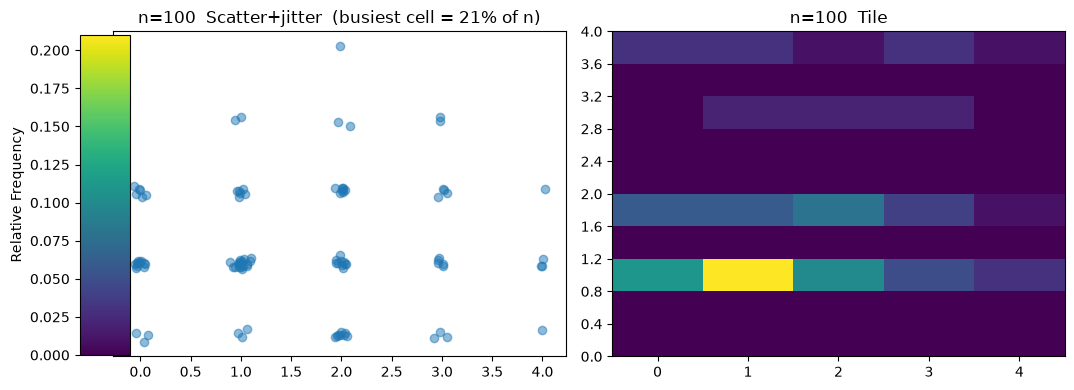

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\3968560023.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


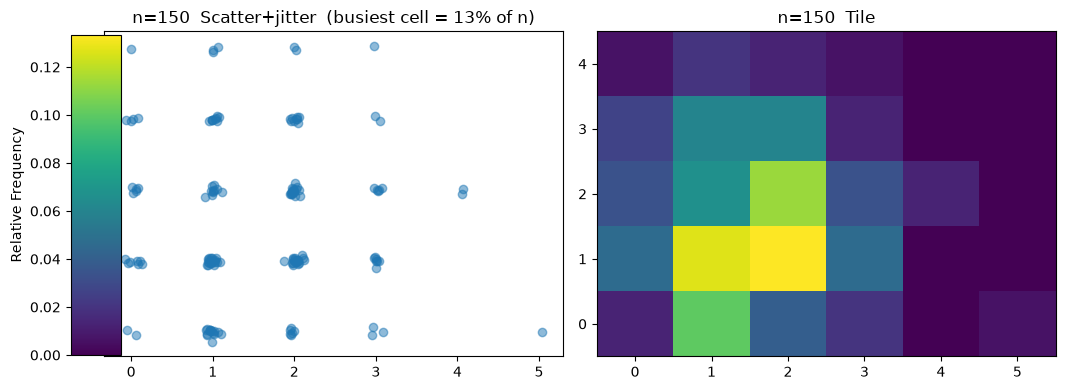

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\3968560023.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


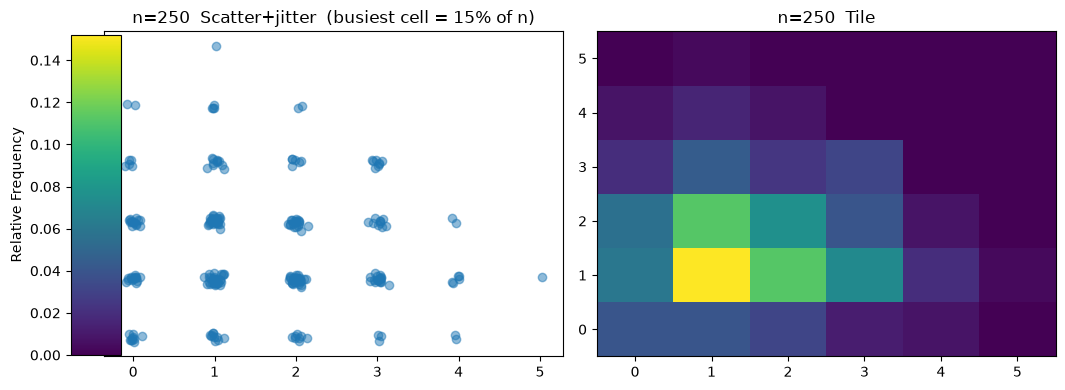

In [54]:
for n in N_SWEEP:
    sim = RV(Binomial(5, 0.3) * Binomial(5, 0.3)).sim(n)
    sim._set_array()
    x, y = sim.array[:, 0], sim.array[:, 1]
    counts = get_counts(list(zip(x, y)))
    crowd_pct = 100 * max(counts.values()) / n
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    plt.sca(axes[0]); sim.plot(type='scatter', jitter=True, alpha=0.5)
    axes[0].set_title(f"n={n}  Scatter+jitter  (busiest cell = {crowd_pct:.0f}% of n)")
    plt.sca(axes[1]); sim.plot(type='tile')
    axes[1].set_title(f"n={n}  Tile")
    fig.tight_layout()
    plt.show()

**Distinct-value sweep**, fixed large n=4000, `RV(DiscreteUniform(1,k) * DiscreteUniform(1,k))`
-- as `k` grows, the heatmap grows to `k x k` cells and jittered scatter has more
room to spread out, so the two defaults may cross over in the opposite direction
from the n-sweep above.

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\1258127772.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


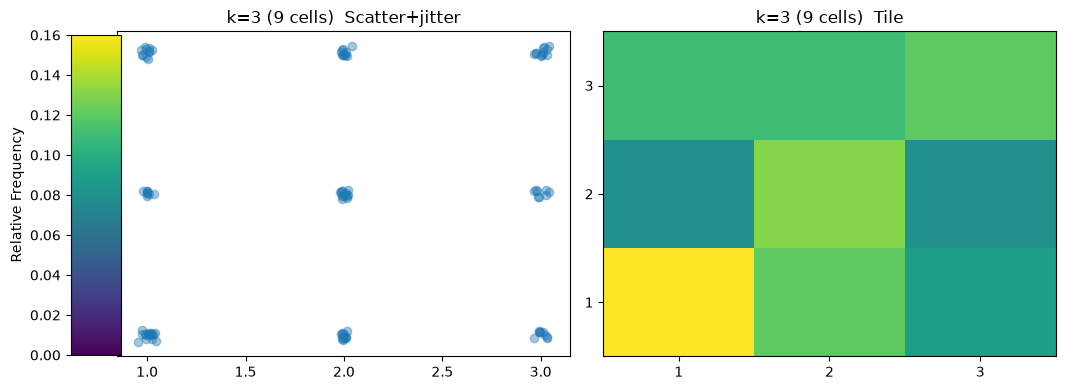

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\1258127772.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


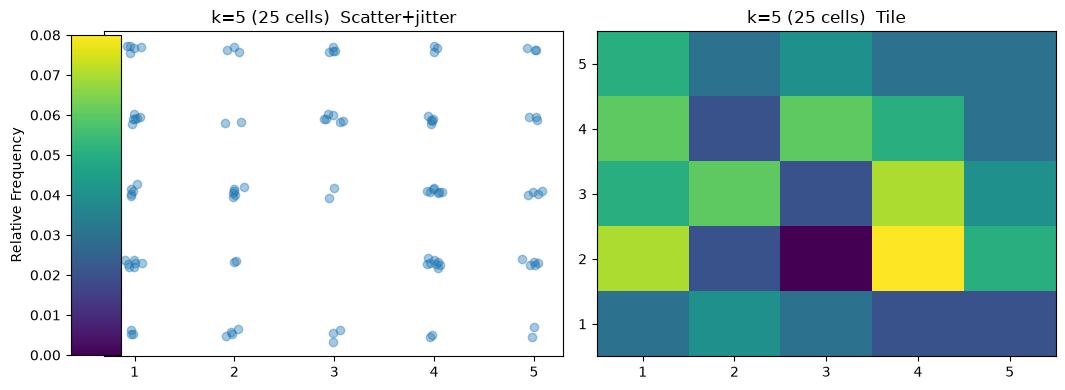

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\1258127772.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


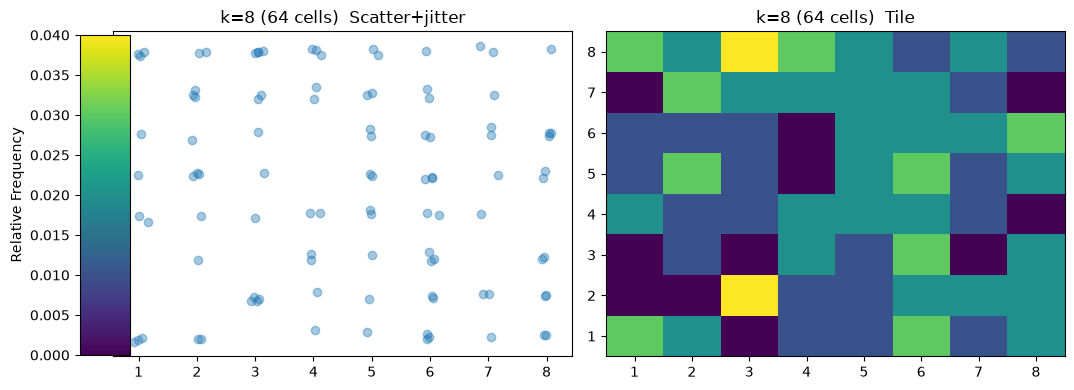

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\1258127772.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


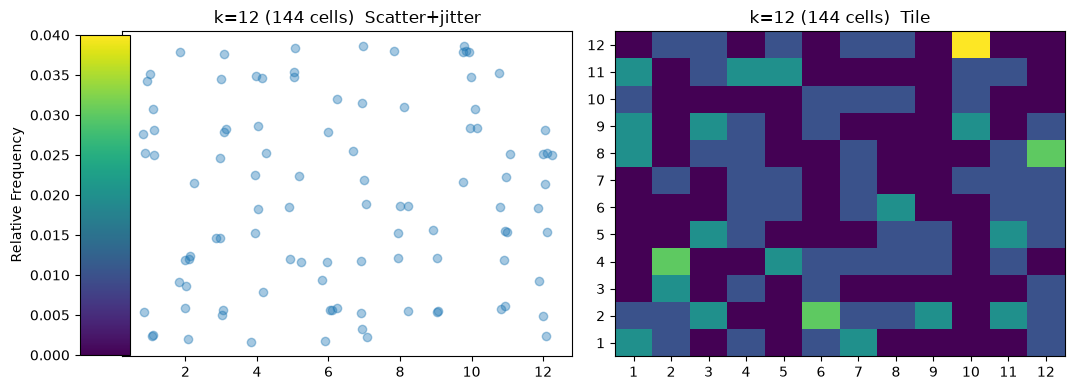

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\1258127772.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


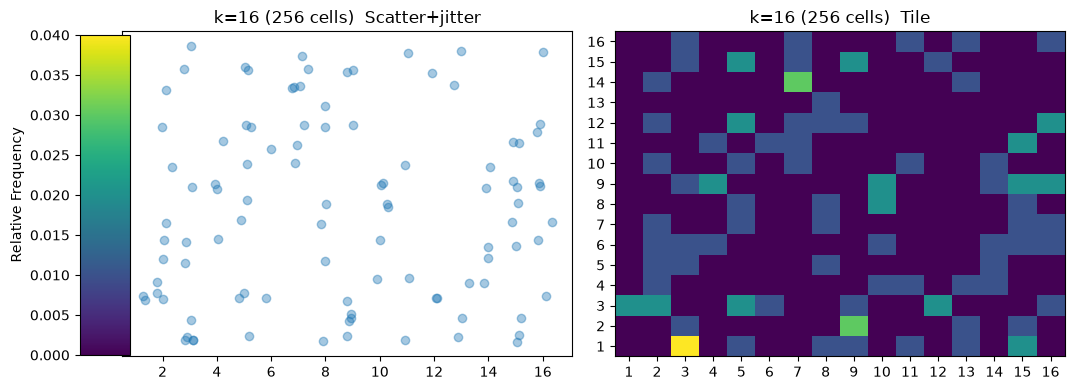

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\1258127772.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


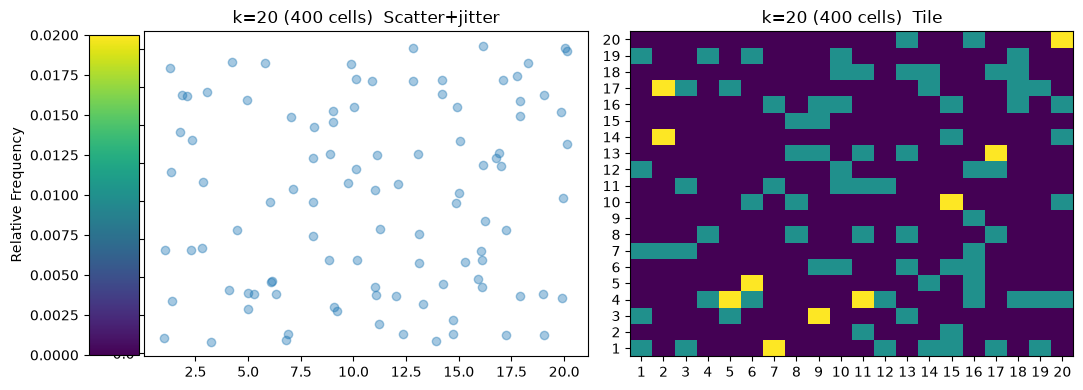

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\1258127772.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


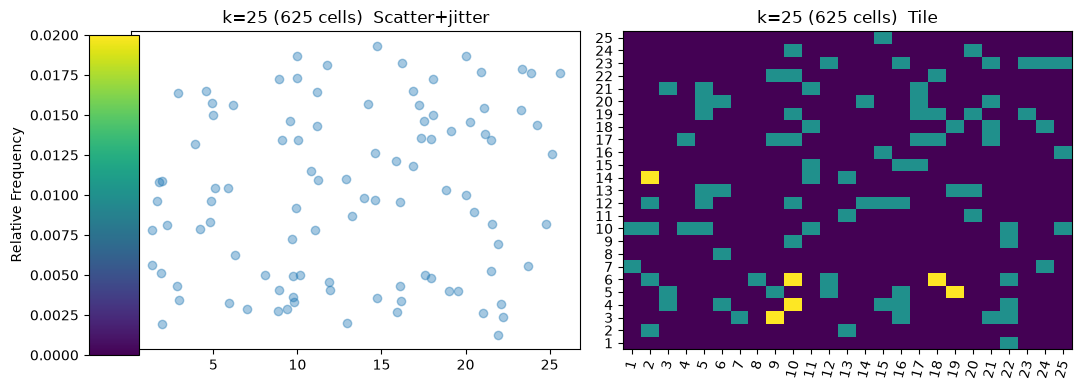

In [55]:
K_SWEEP_2D = [3, 5, 8, 12, 16, 20, 25]

for k in K_SWEEP_2D:
    sim = RV(DiscreteUniform(1, k) * DiscreteUniform(1, k)).sim(100)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    plt.sca(axes[0]); sim.plot(type='scatter', jitter=True, alpha=0.4)
    axes[0].set_title(f"k={k} ({k*k} cells)  Scatter+jitter")
    plt.sca(axes[1]); sim.plot(type='tile')
    axes[1].set_title(f"k={k} ({k*k} cells)  Tile")
    fig.tight_layout()
    plt.show()

**"Scatter with Size" alternative** (bubble grid) [CUSTOM], shown at a couple of
`n` for reference against the two defaults above:

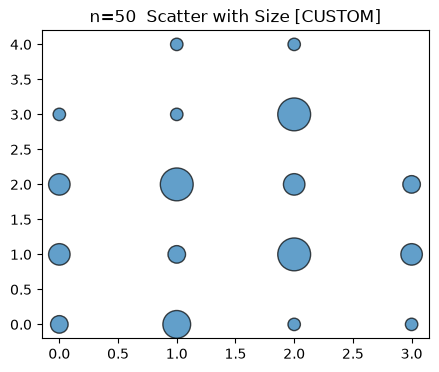

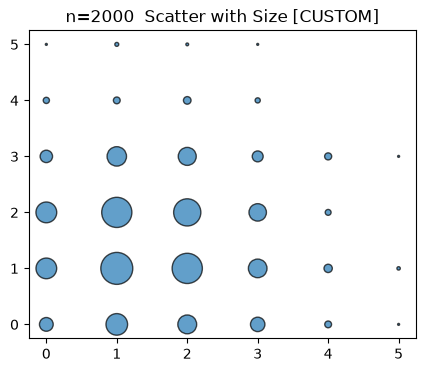

In [56]:
for n in [50, 2000]:
    sim = RV(Binomial(5, 0.3) * Binomial(5, 0.3)).sim(n)
    sim._set_array()
    x, y = sim.array[:, 0], sim.array[:, 1]
    fig, ax = plt.subplots(figsize=(5, 4))
    bubble_grid(ax, x, y, title=f"n={n}  Scatter with Size [CUSTOM]")
    plt.show()

_Notes -- 2D discrete x discrete crossover n, and distinct-value crossover:_

- Crossover n (scatter+jitter -> tile):
- Distinct-value crossover (does tile stop scaling well past some k? does jitter get *better* with larger k?):


---
## 4. 2D continuous x continuous -- `RV(Normal() * Normal())`

Small n default: **Scatter** (native `type='scatter'`). Large n default: **Density**
(native `type='density'`). Each `n` also prints `nn_overplot_score` (mean
nearest-neighbor distance normalized by spread -- smaller means more overplotted).

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\3805699529.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


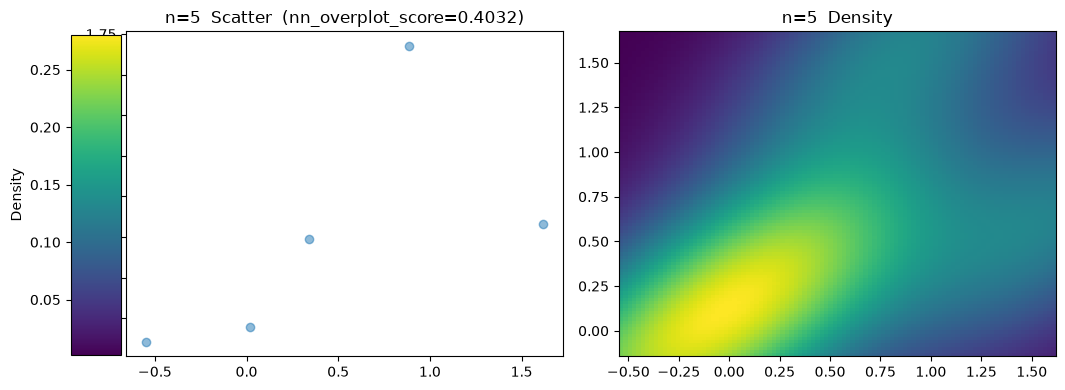

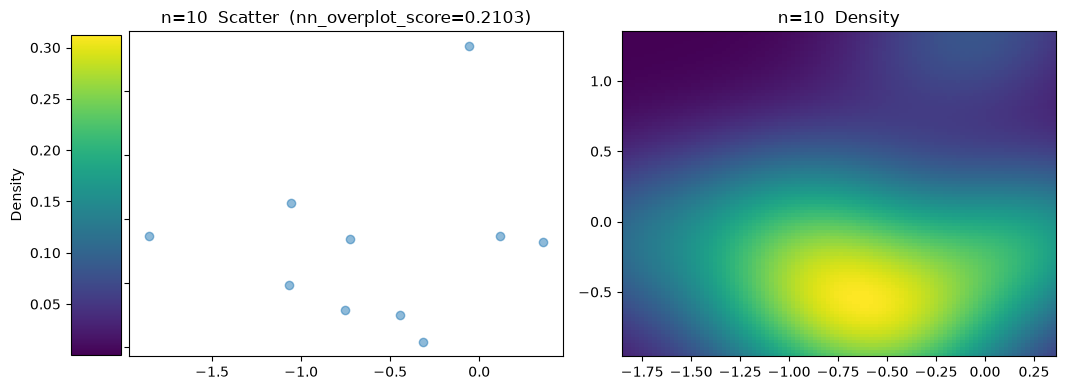

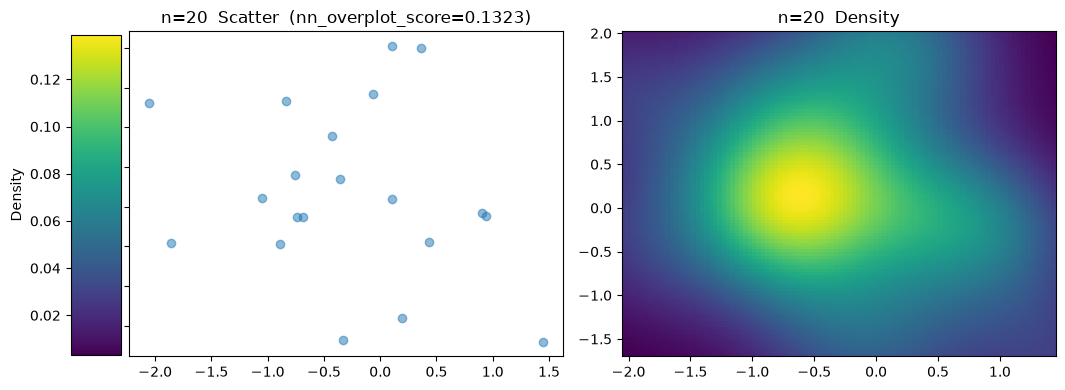

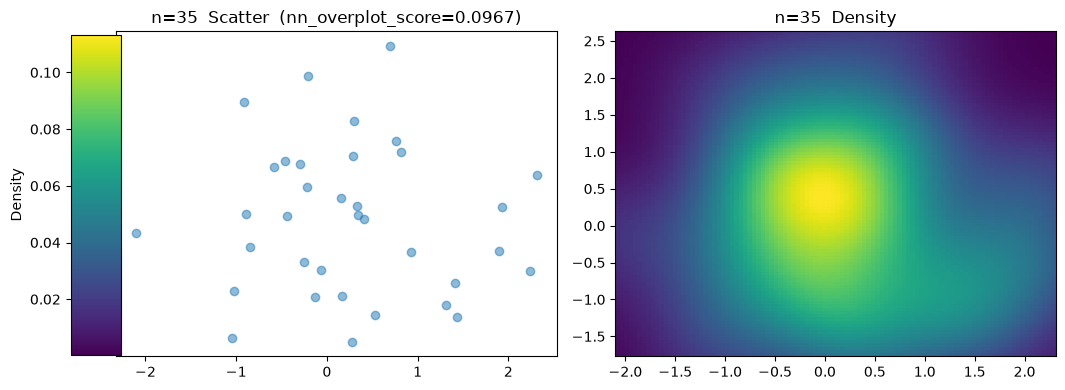

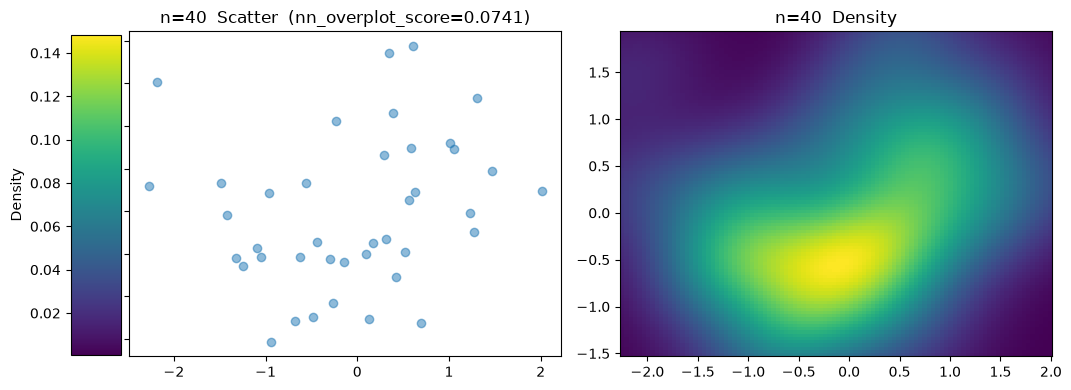

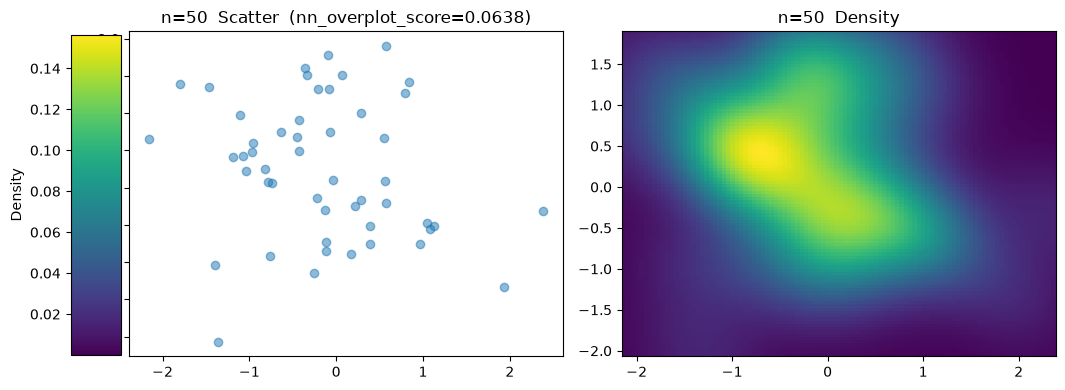

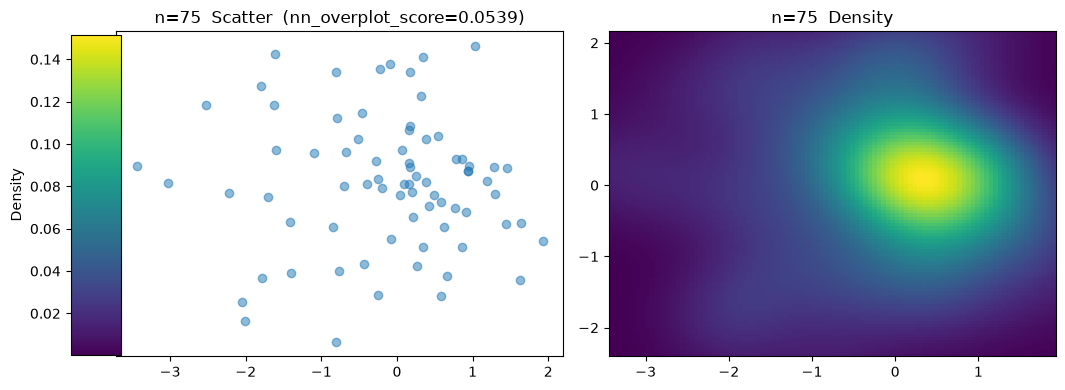

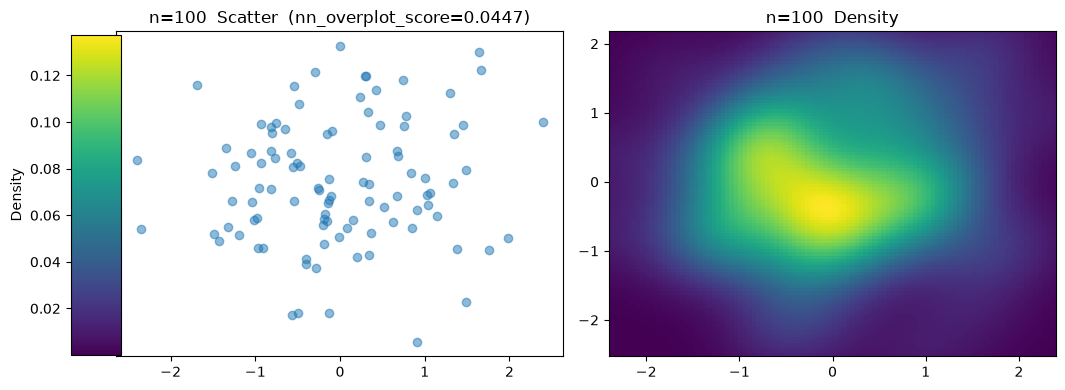

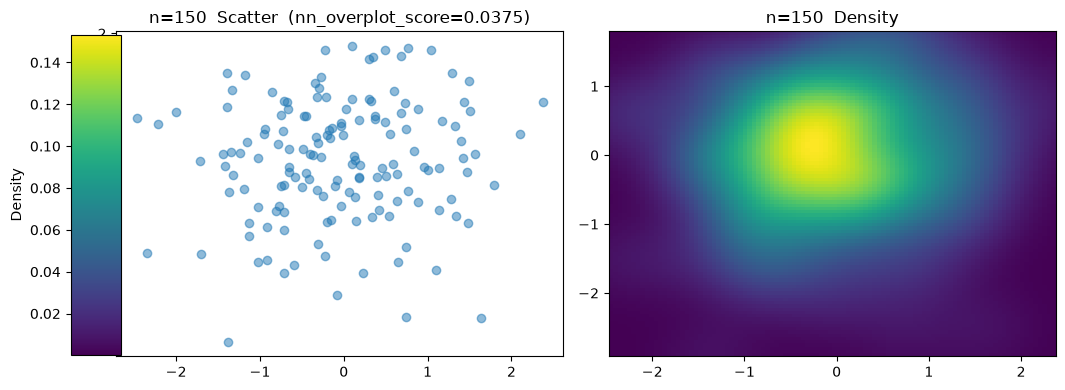

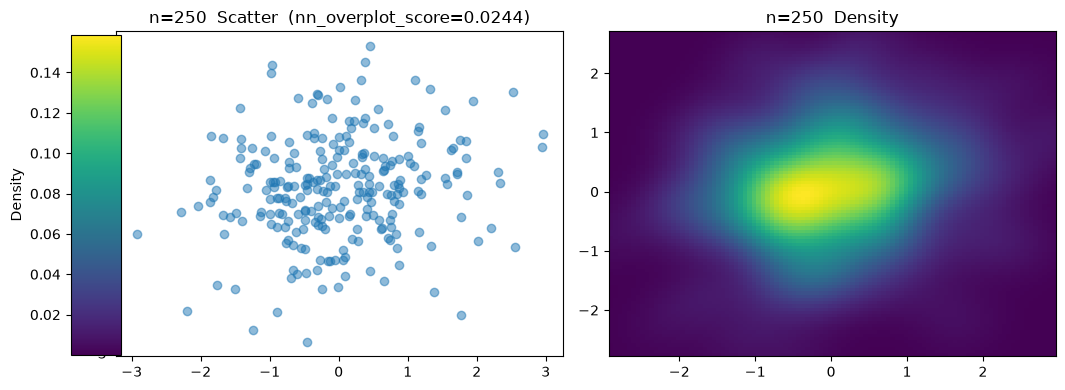

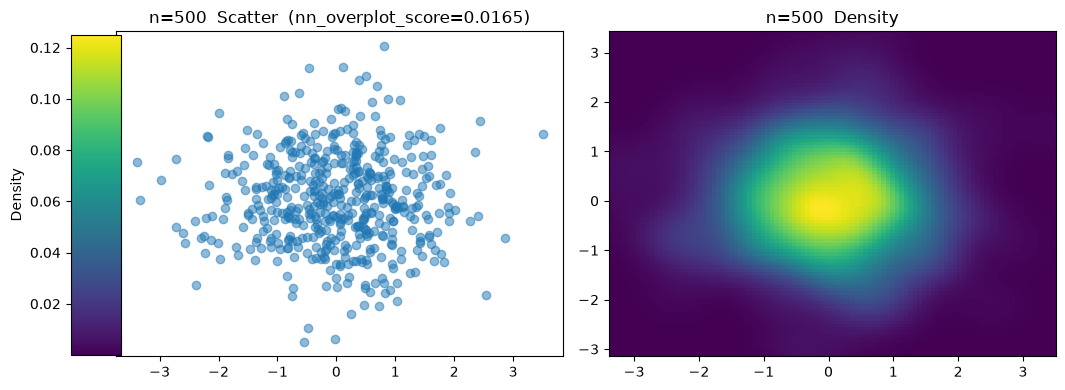

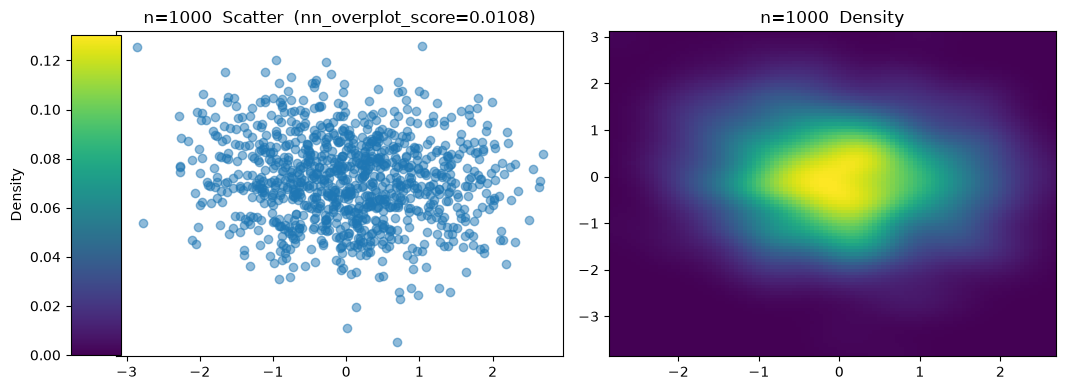

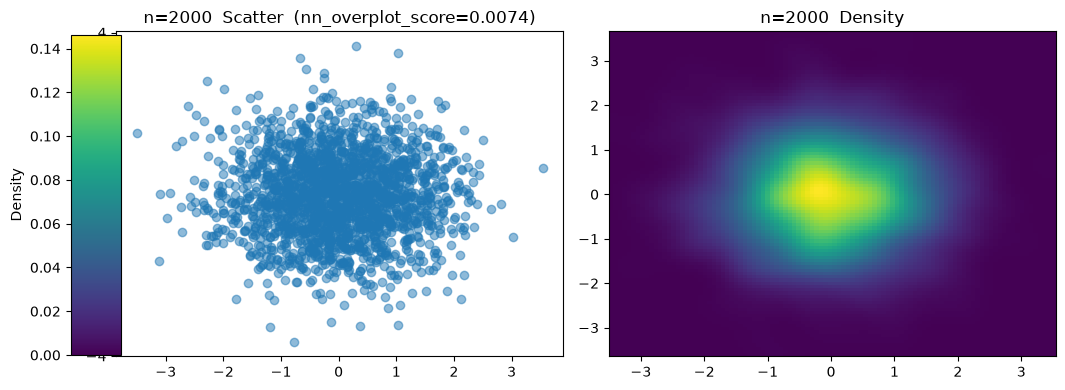

In [57]:
for n in N_SWEEP + [500, 1000, 2000]:
    sim = RV(Normal() * Normal()).sim(n)
    sim._set_array()
    x, y = sim.array[:, 0], sim.array[:, 1]
    score = nn_overplot_score(x, y)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    plt.sca(axes[0]); sim.plot(type='scatter', alpha=0.5)
    axes[0].set_title(f"n={n}  Scatter  (nn_overplot_score={score:.4f})")
    plt.sca(axes[1]); sim.plot(type='density')
    axes[1].set_title(f"n={n}  Density")
    fig.tight_layout()
    plt.show()

_Notes -- 2D continuous x continuous crossover n:_

- 

---
## 5. 2D discrete x continuous -- `RV(Binomial(5, 0.3) * Normal())`

Small n default: **Scatter (segmented strip plot)** (native `type='scatter', jitter=True`
on a discrete-x axis reads as a strip plot per group). Large n default:
**Violin/Box + Density** [CUSTOM: `violin_plus_density`].

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\2356406585.py:49: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.violinplot(groups, positions=positions, showmedians=True, vert=vert)


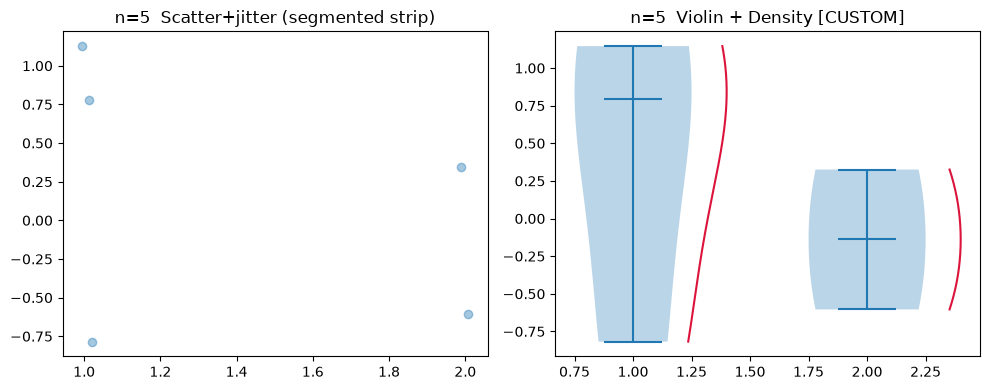

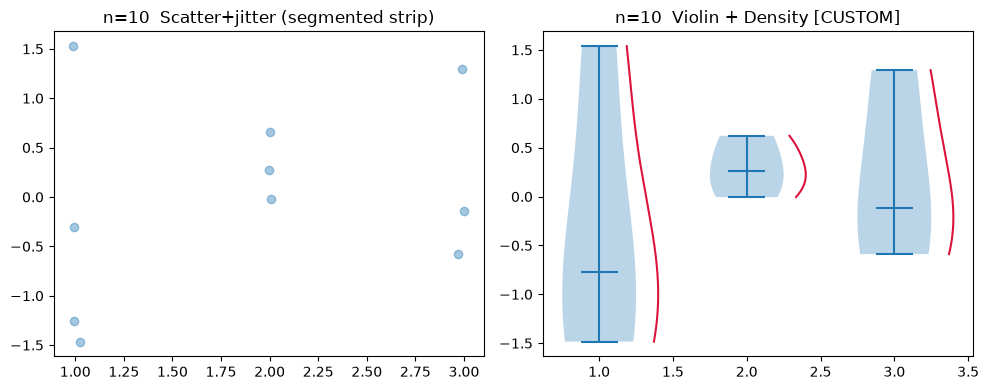

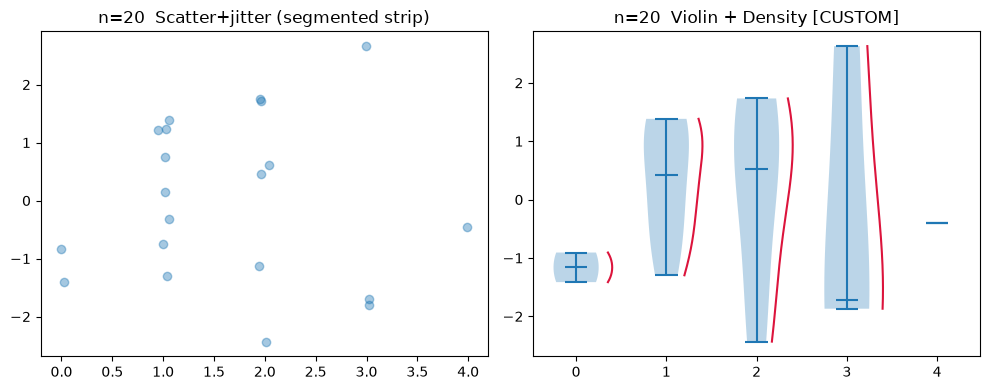

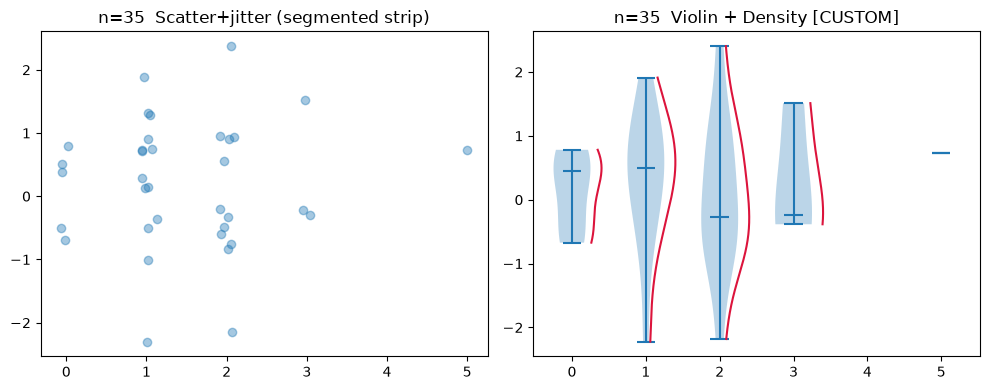

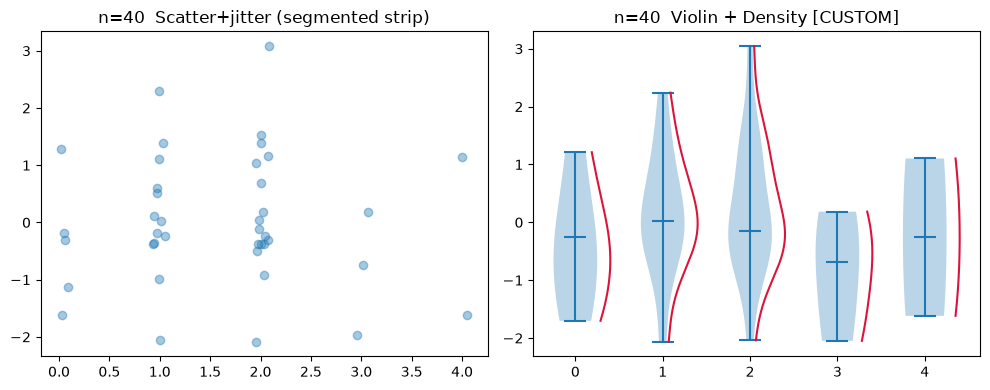

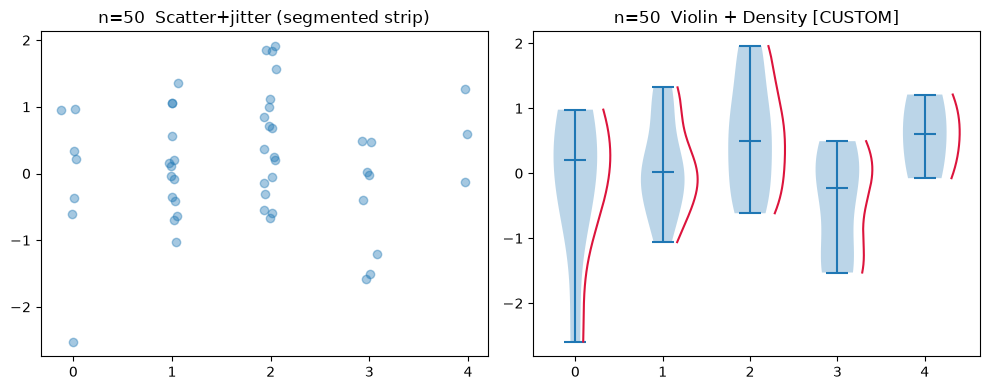

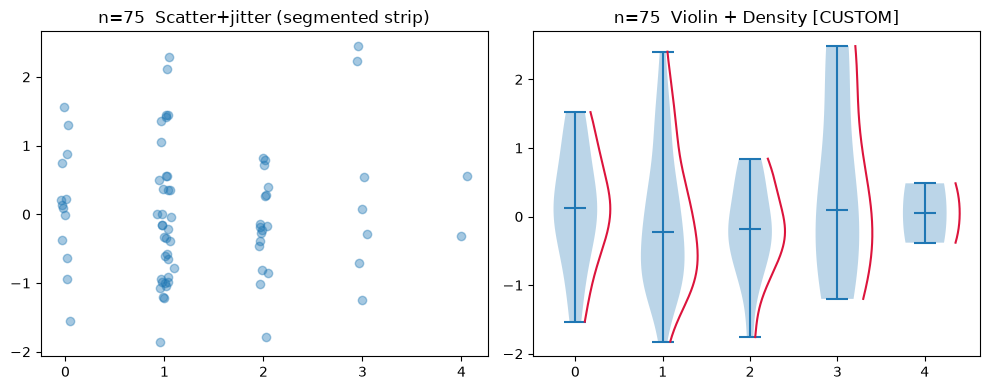

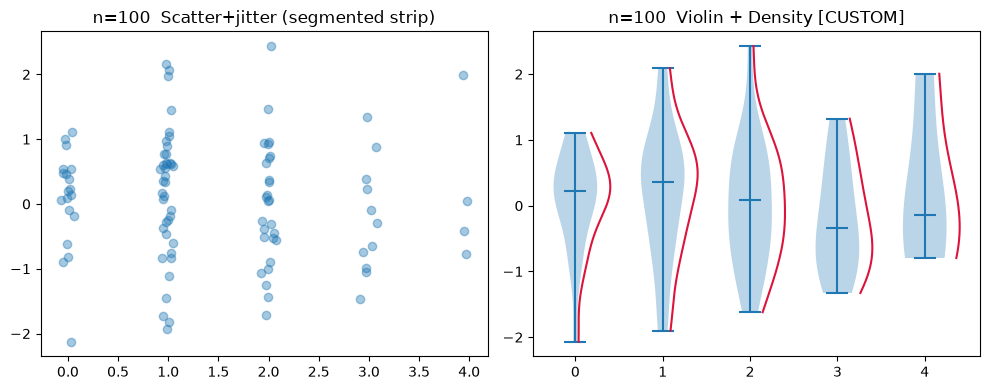

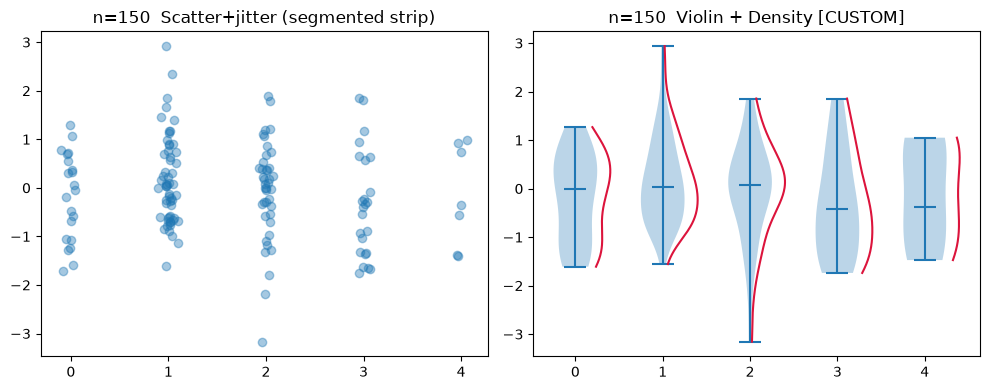

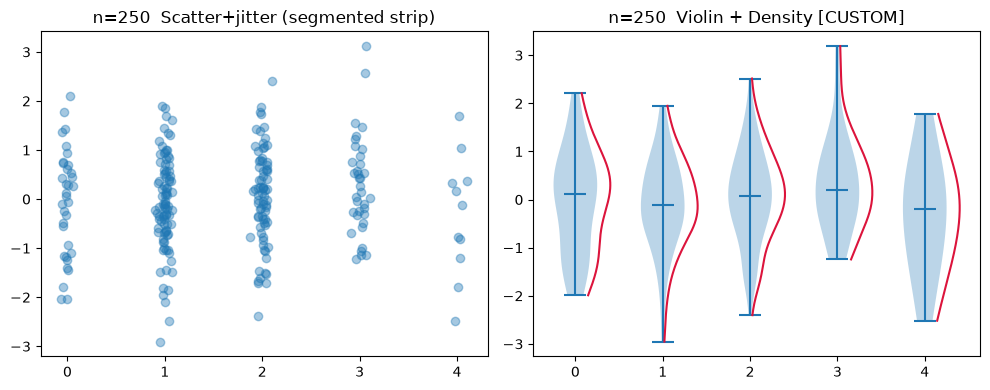

In [58]:
for n in N_SWEEP:
    sim = RV(Binomial(5, 0.3) * Normal()).sim(n)
    sim._set_array()
    x, y = sim.array[:, 0], sim.array[:, 1]
    groups = {xv: y[x == xv] for xv in sorted(set(x))}
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    plt.sca(axes[0]); sim.plot(type='scatter', jitter=True, alpha=0.4)
    axes[0].set_title(f"n={n}  Scatter+jitter (segmented strip)")
    violin_plus_density(axes[1], groups, vert=True, title=f"n={n}  Violin + Density [CUSTOM]")
    fig.tight_layout()
    plt.show()

**Distinct-value sweep**, fixed large n=3000, `RV(DiscreteUniform(1,k) * Normal())` --
does the violin+density default stay readable as the number of groups grows?

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\2356406585.py:49: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.violinplot(groups, positions=positions, showmedians=True, vert=vert)


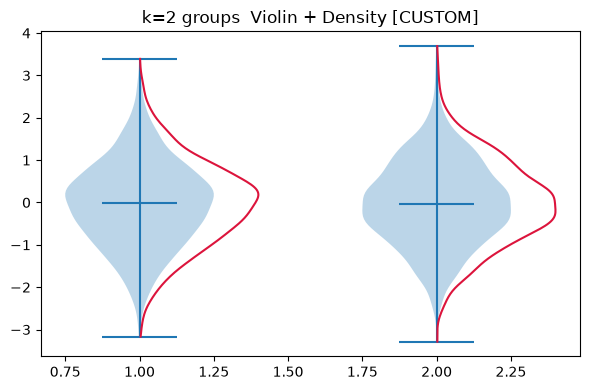

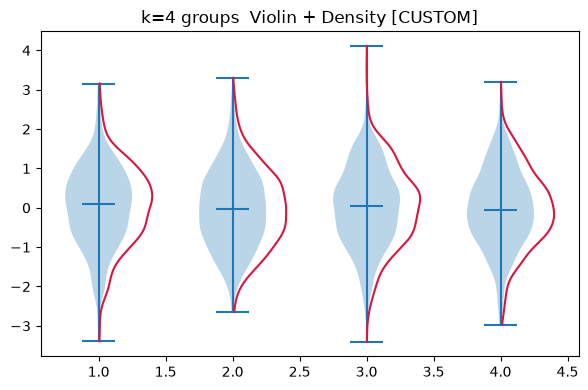

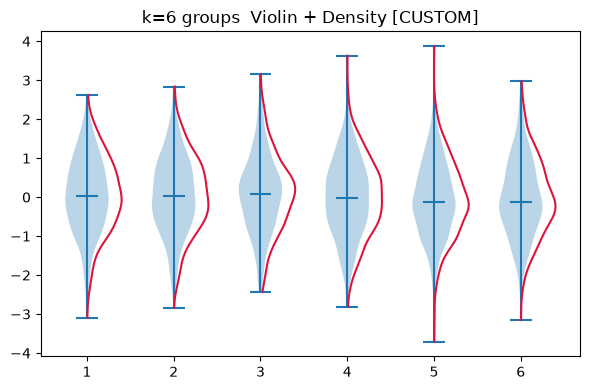

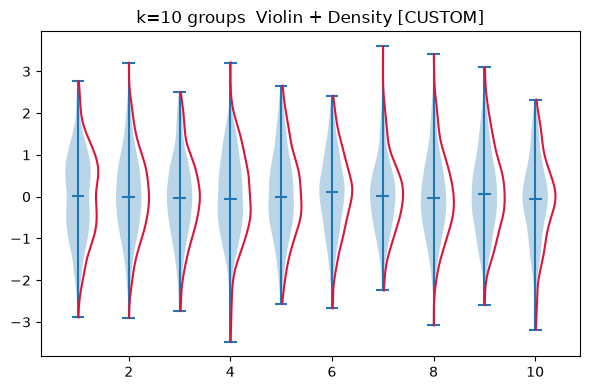

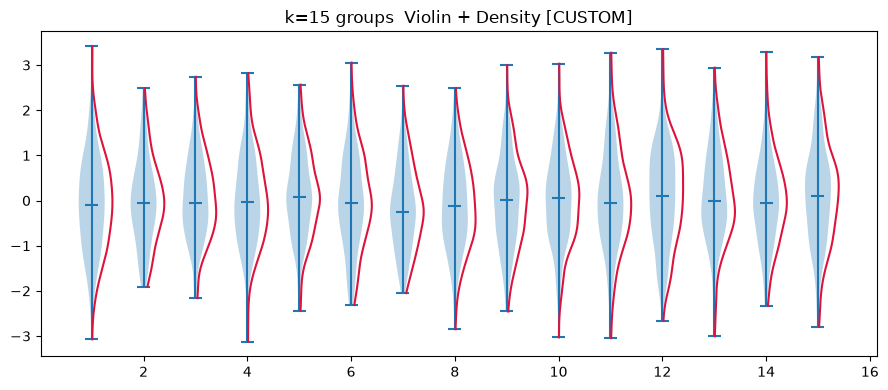

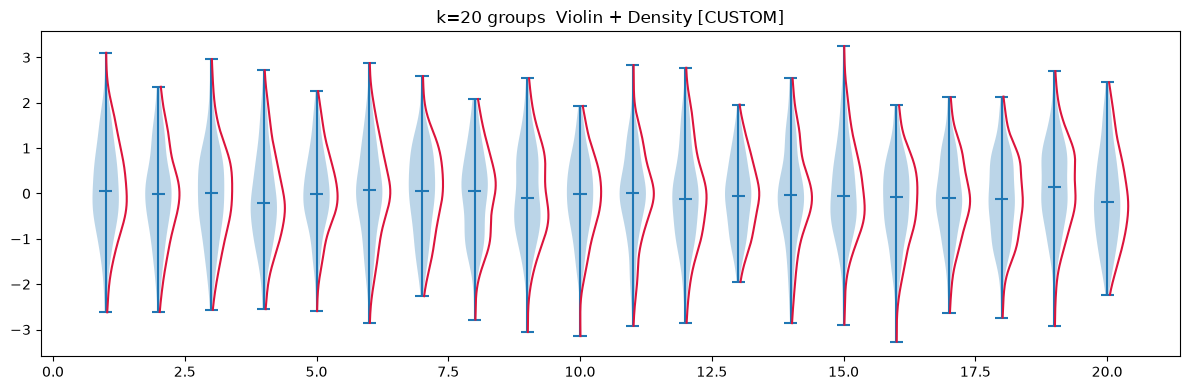

In [59]:
for k in [2, 4, 6, 10, 15, 20]:
    sim = RV(DiscreteUniform(1, k) * Normal()).sim(3000)
    sim._set_array()
    x, y = sim.array[:, 0], sim.array[:, 1]
    groups = {xv: y[x == xv] for xv in sorted(set(x))}
    fig, ax = plt.subplots(figsize=(max(6, 0.6 * k), 4))
    violin_plus_density(ax, groups, vert=True, title=f"k={k} groups  Violin + Density [CUSTOM]")
    fig.tight_layout()
    plt.show()

_Notes -- 2D discrete x continuous crossover n, and group-count limit for violin+density:_

- Crossover n:
- Max readable number of groups:


---
## 6. 2D continuous x discrete -- `RV(Normal() * Binomial(5, 0.3))`

Mirror of section 5 with axes swapped (continuous X, discrete Y) -- violin
orientation flips to horizontal (`vert=False`). Shown briefly since the
underlying mechanics are identical to section 5.

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\2356406585.py:49: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.violinplot(groups, positions=positions, showmedians=True, vert=vert)


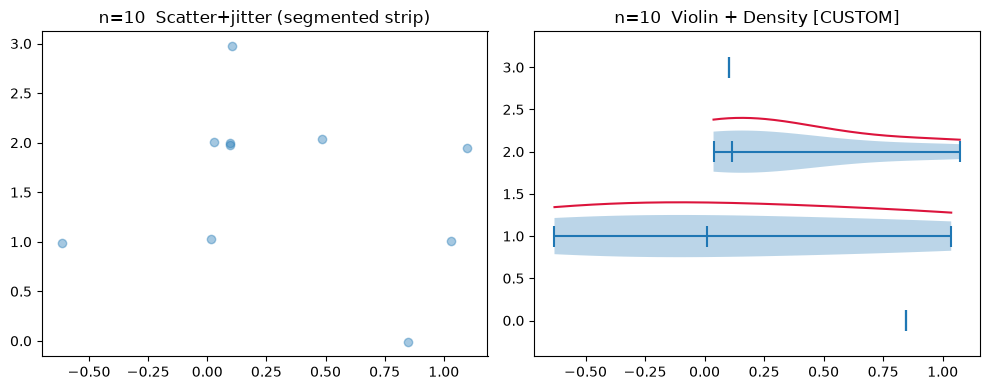

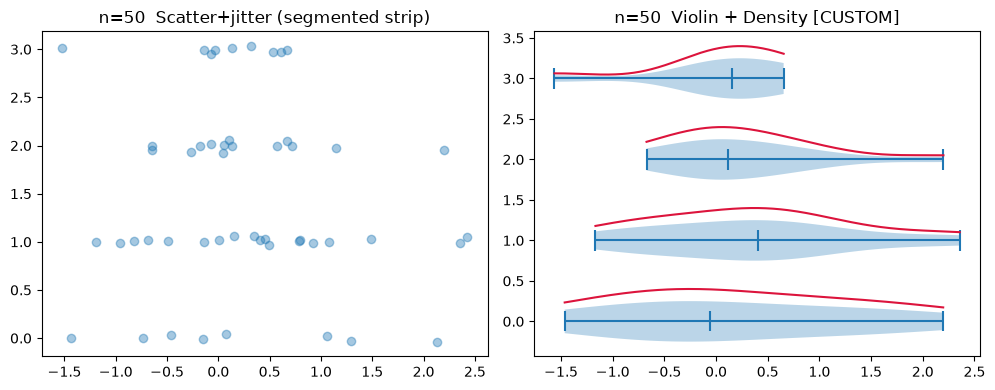

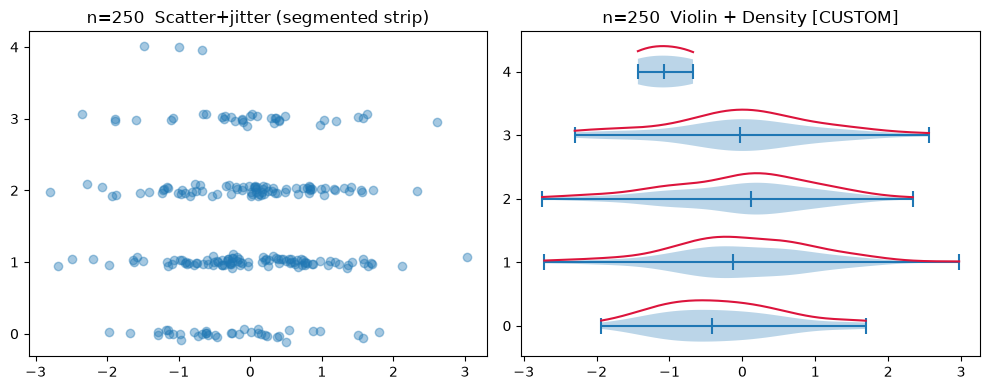

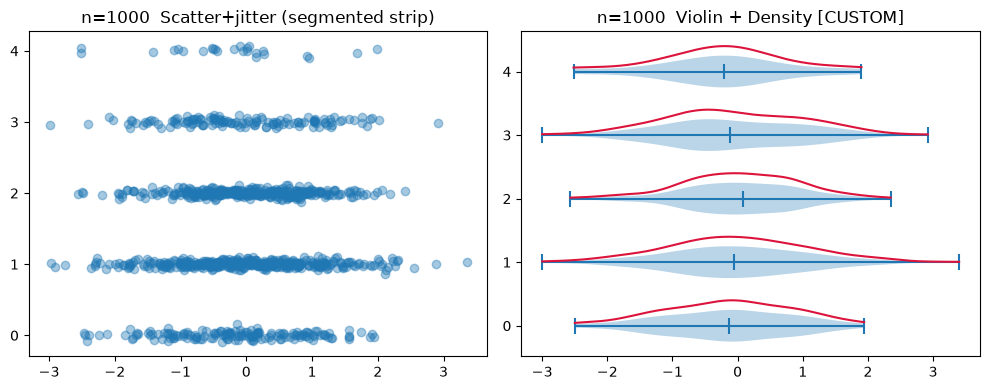

In [60]:
for n in [10, 50, 250, 1000]:
    sim = RV(Normal() * Binomial(5, 0.3)).sim(n)
    sim._set_array()
    x, y = sim.array[:, 0], sim.array[:, 1]
    groups = {yv: x[y == yv] for yv in sorted(set(y))}
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    plt.sca(axes[0]); sim.plot(type='scatter', jitter=True, alpha=0.4)
    axes[0].set_title(f"n={n}  Scatter+jitter (segmented strip)")
    violin_plus_density(axes[1], groups, vert=False, title=f"n={n}  Violin + Density [CUSTOM]")
    fig.tight_layout()
    plt.show()

_Notes -- confirm section 5's crossover n applies here too (orientation swap only):_

- 

---
## 7. Process time point, discrete-valued -- `PoissonProcess(rate=1)[2]`

Small n default: **Dot Plot** [CUSTOM]. Large n default: **Impulse** (native).
The distinct-value behavior here is governed by the same Poisson-count mechanics
as section 1's `n_unique_threshold` sweep (the count at a fixed time point is
itself Poisson-distributed), so it isn't re-swept separately -- see section 1.

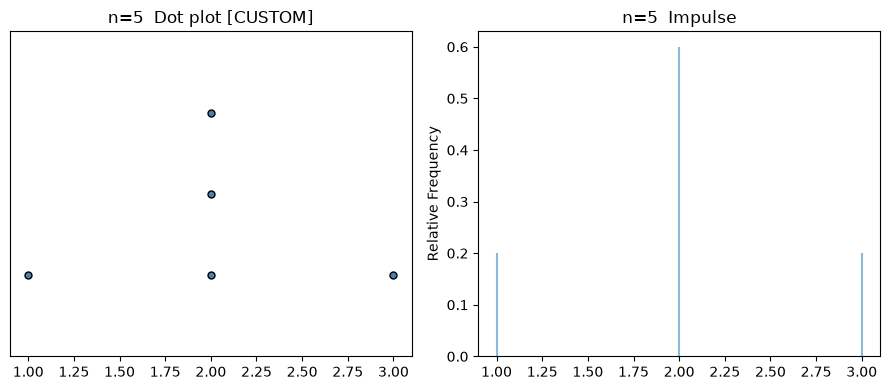

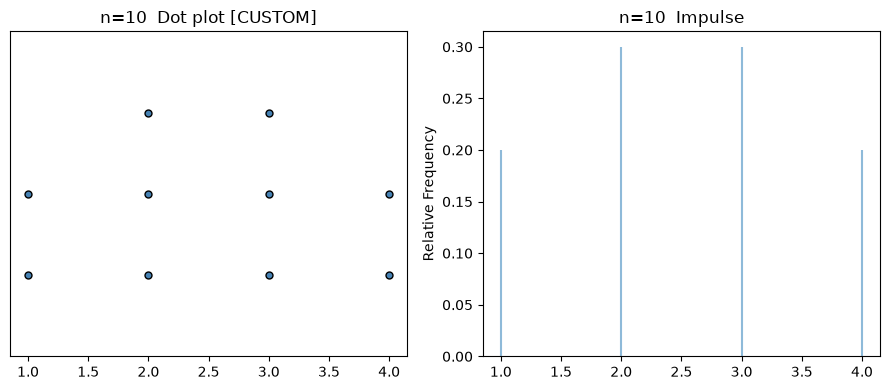

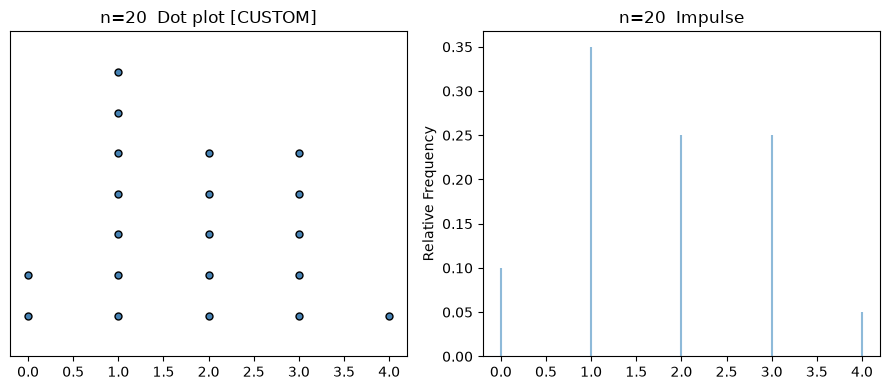

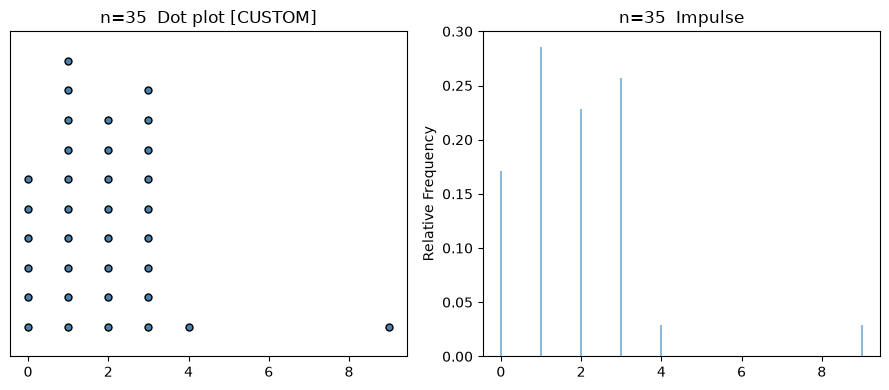

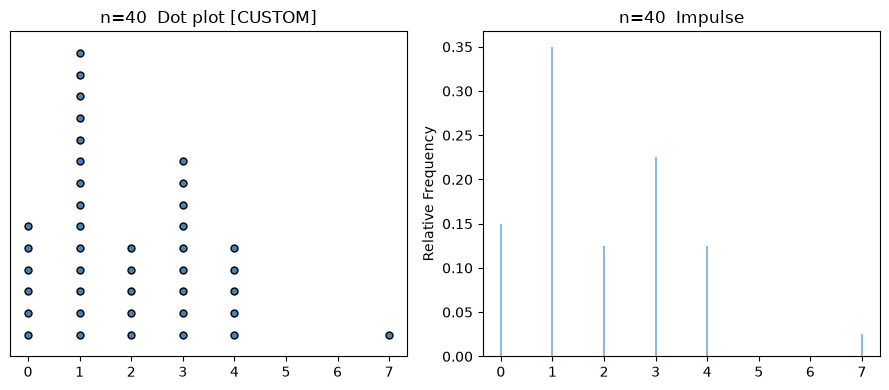

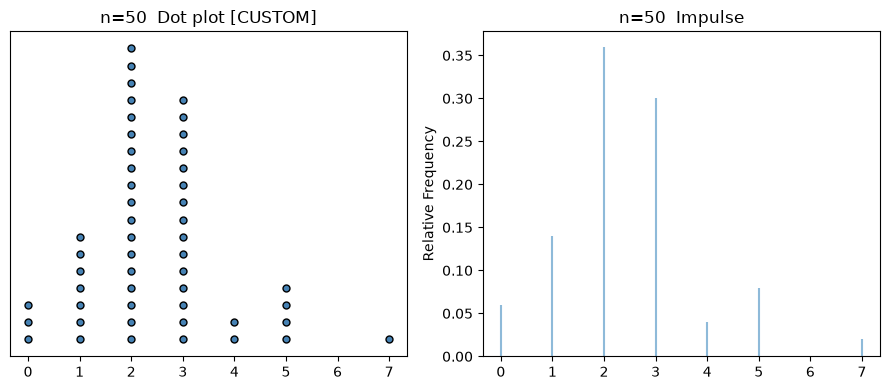

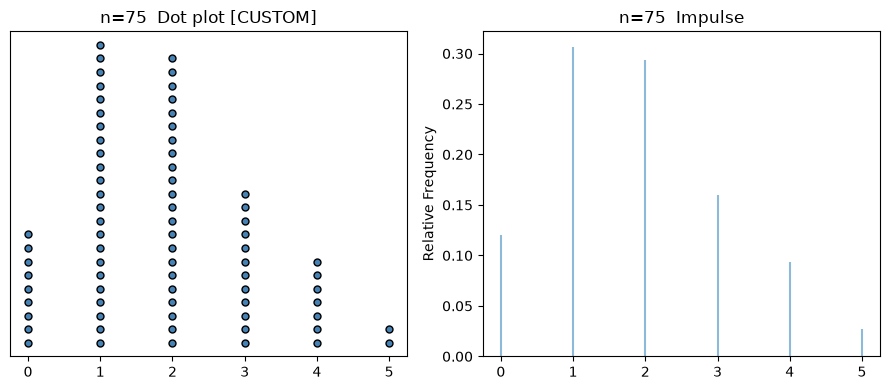

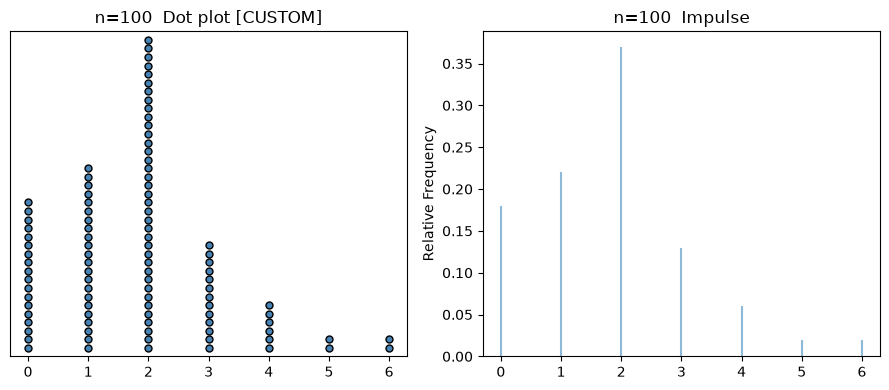

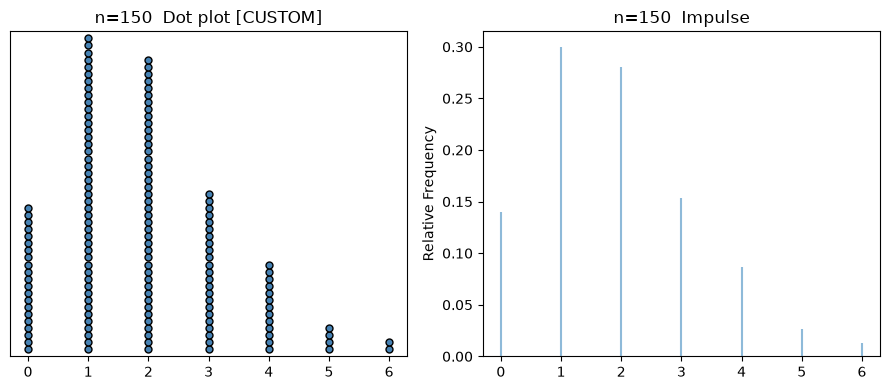

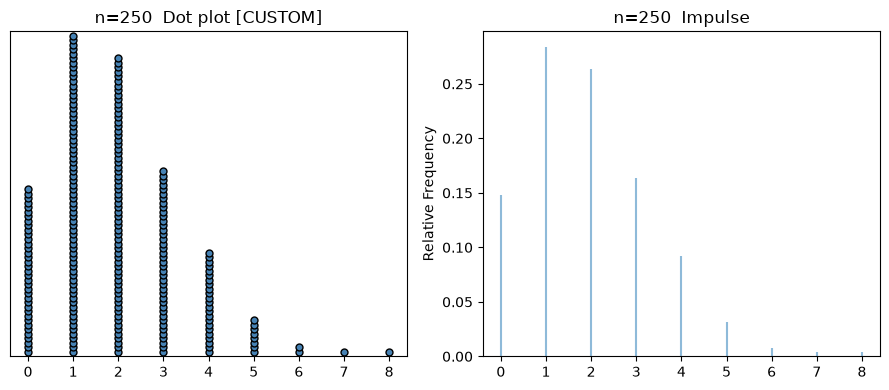

In [61]:
for n in N_SWEEP:
    sim = PoissonProcess(rate=1)[2].sim(n)
    sim._set_array()
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    dot_plot(axes[0], sim.array, title=f"n={n}  Dot plot [CUSTOM]")
    plt.sca(axes[1])
    sim.plot(type='impulse')
    axes[1].set_title(f"n={n}  Impulse")
    fig.tight_layout()
    plt.show()

_Notes -- process time point (discrete) crossover n:_

- 

---
## 8. Process time point, continuous-valued -- `BrownianMotion()[1]`

Small n default: **Strip plot** [CUSTOM]. Large n default: **Histogram** (native `type='hist'`).

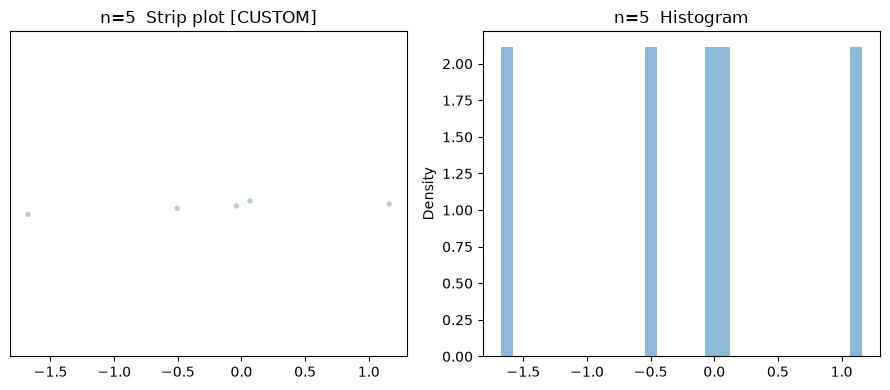

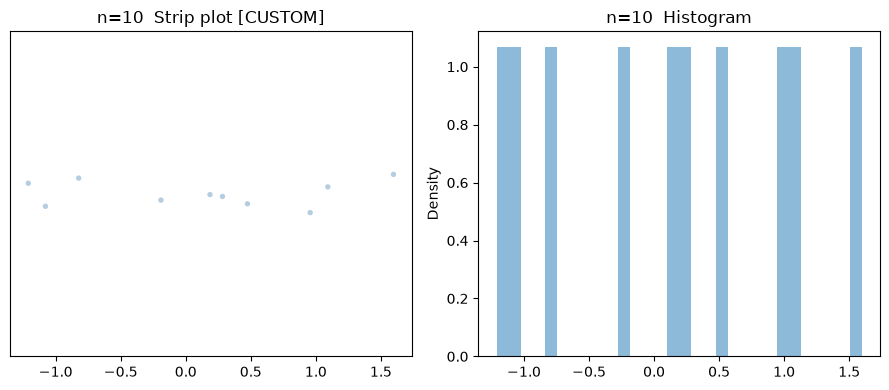

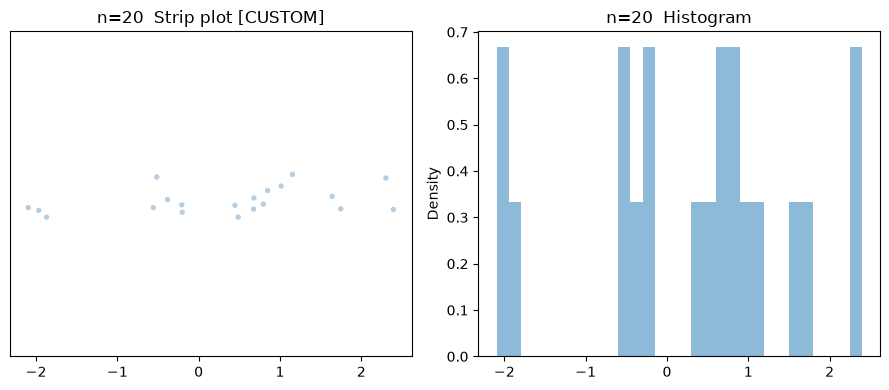

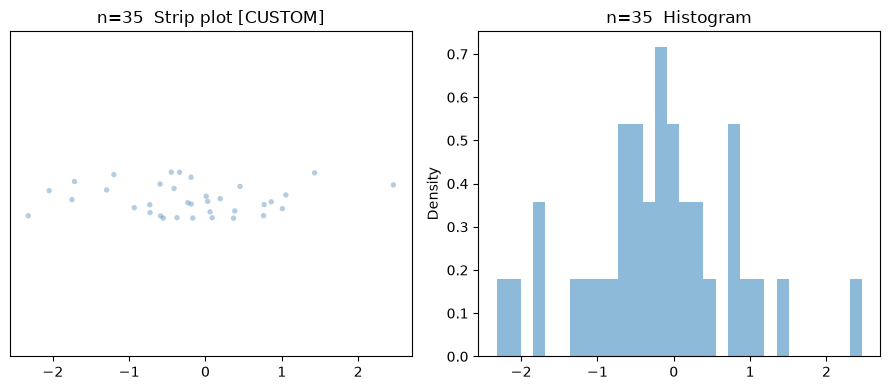

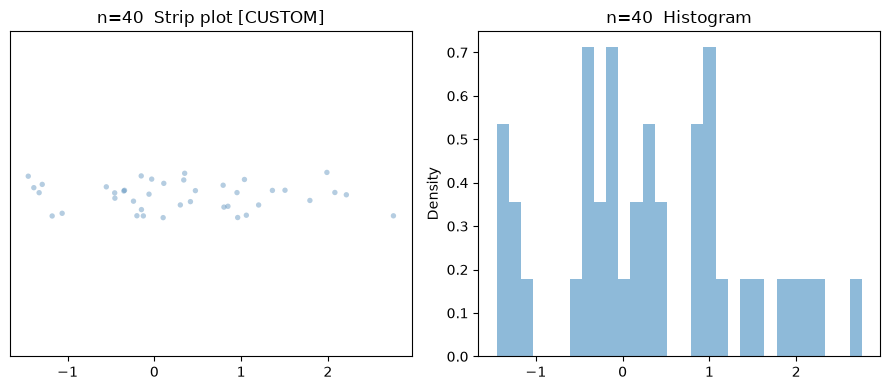

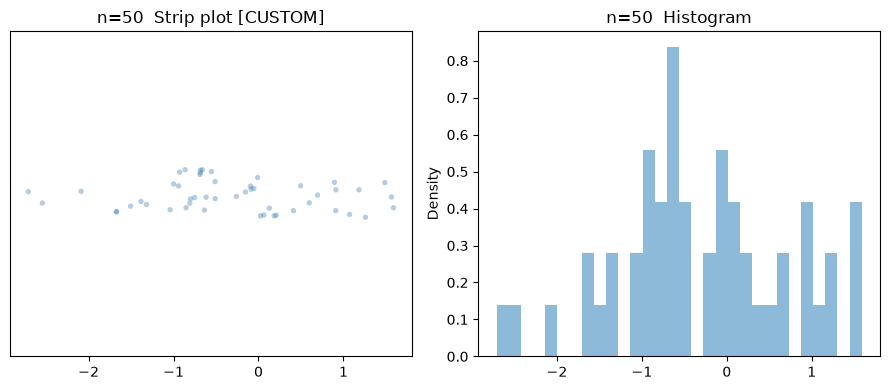

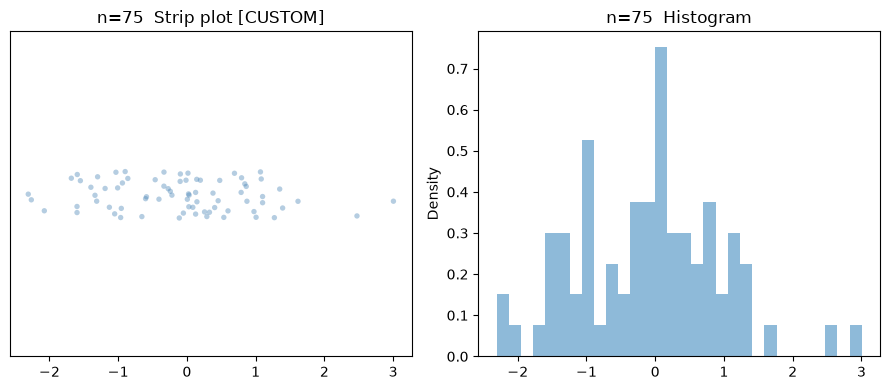

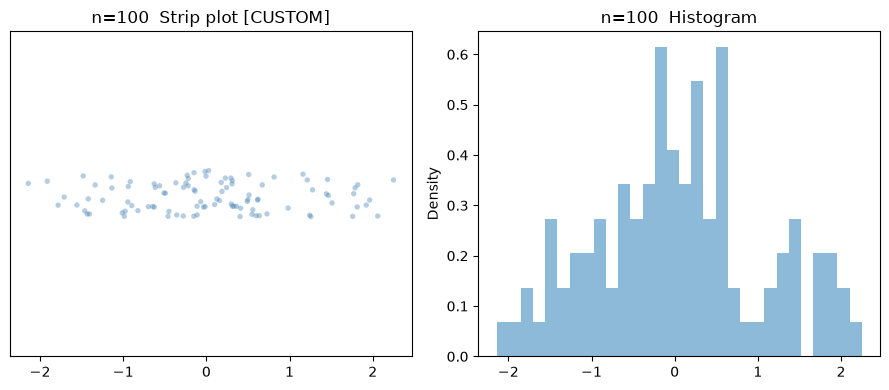

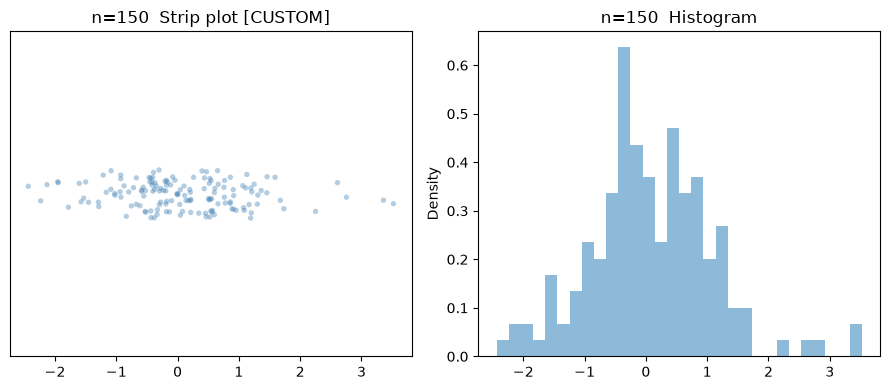

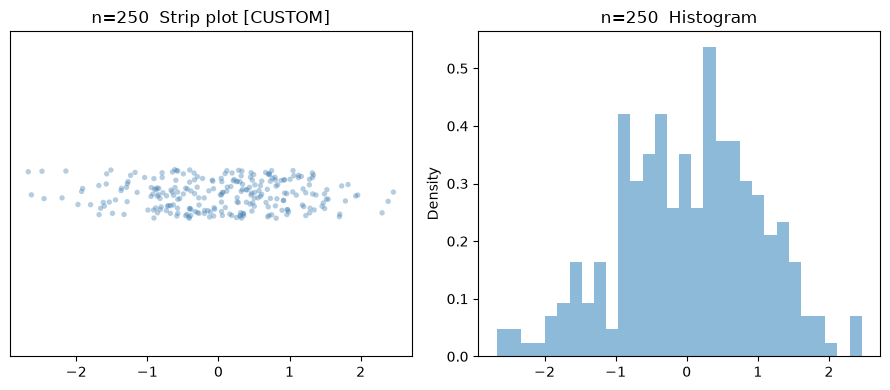

In [62]:
for n in N_SWEEP:
    sim = BrownianMotion()[1].sim(n)
    sim._set_array()
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    strip_plot(axes[0], sim.array, title=f"n={n}  Strip plot [CUSTOM]")
    plt.sca(axes[1])
    sim.plot(type='hist')
    axes[1].set_title(f"n={n}  Histogram")
    fig.tight_layout()
    plt.show()

_Notes -- process time point (continuous) crossover n:_

- 

---
## 9. 1D categorical/string -- `BoxModel(['A', 'B', 'C', 'D', 'E'])`

Symbulate can't plot string-valued RVs at all today (see the categorical finding
in `design_plot_lookup_exploration.ipynb`), so both defaults here are entirely
`[CUSTOM]`, built directly from the raw simulated outcomes (`sim.results`),
bypassing `RV`/`.plot()` completely. Small n default: **Dot plot**. Large n
default: **Impulse**.

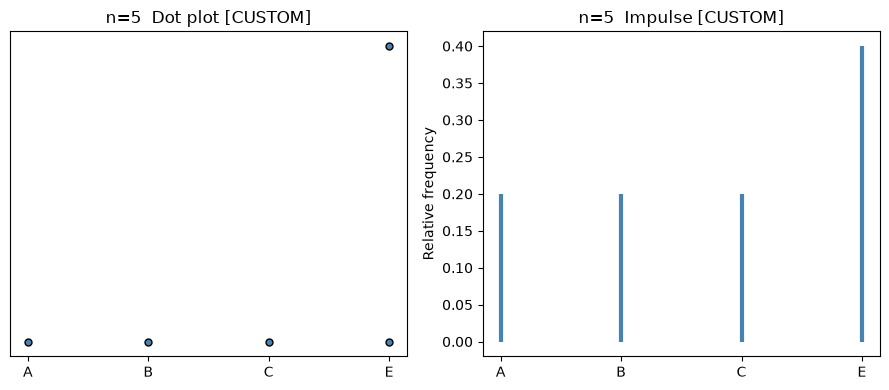

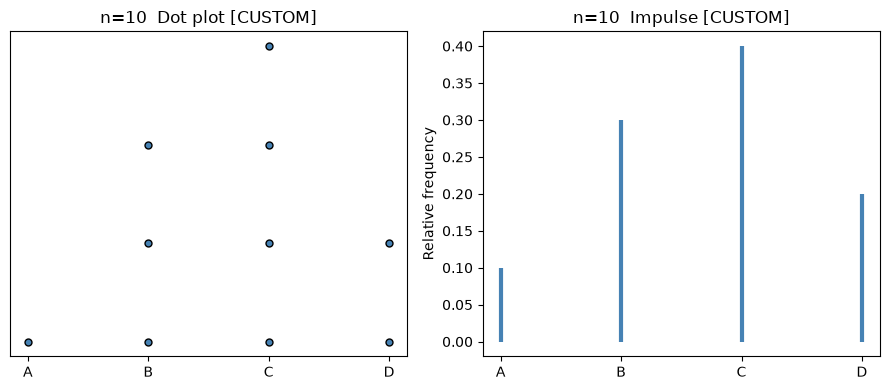

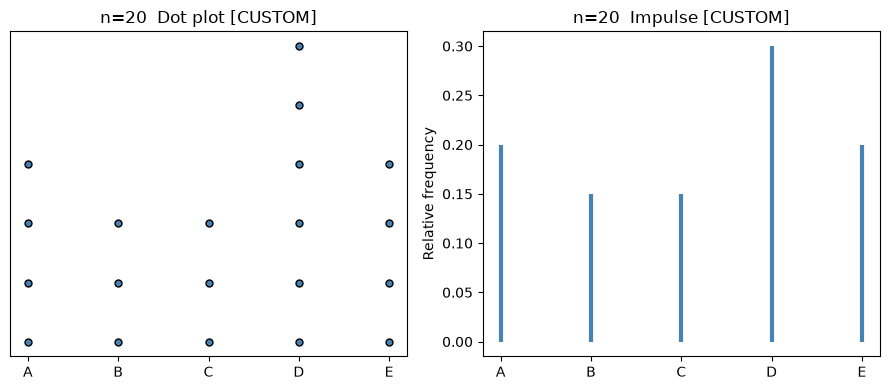

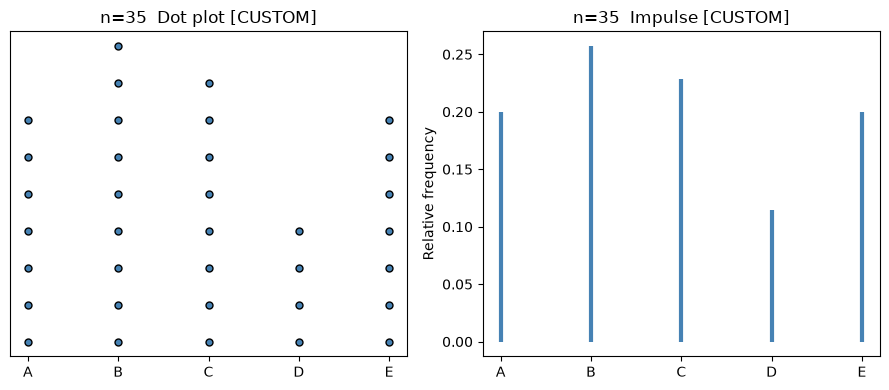

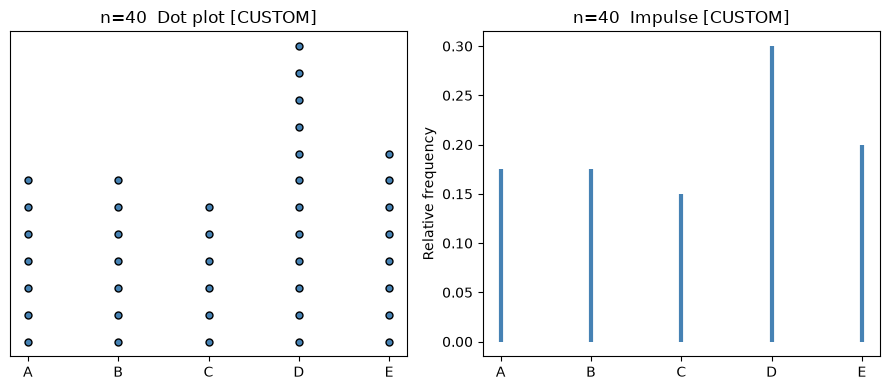

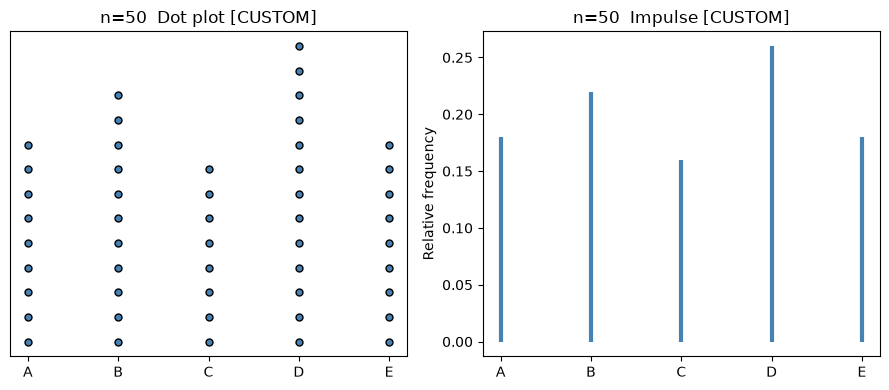

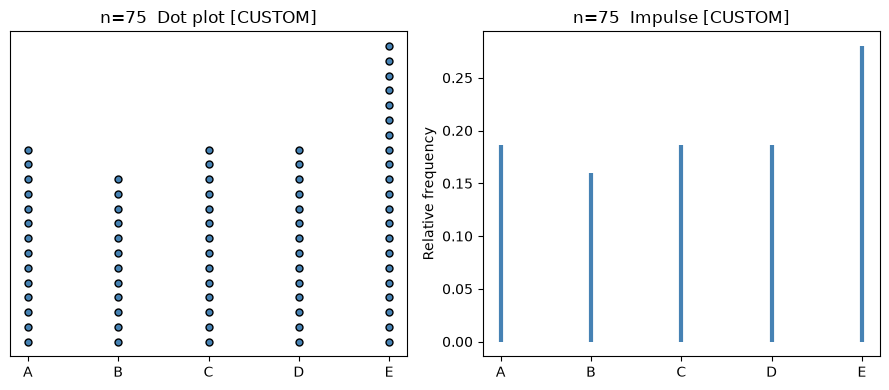

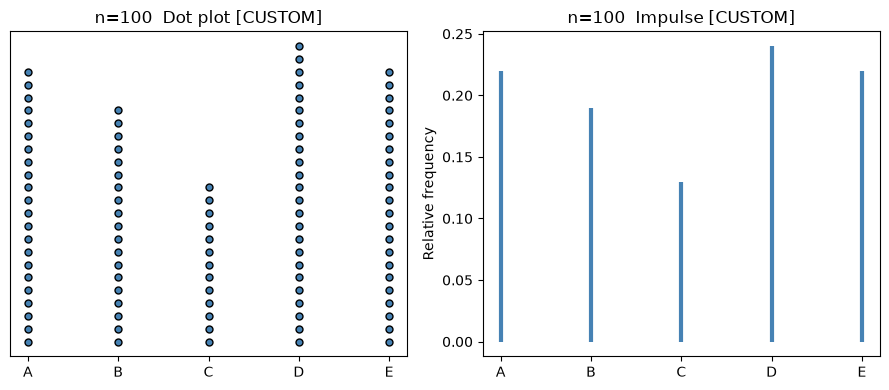

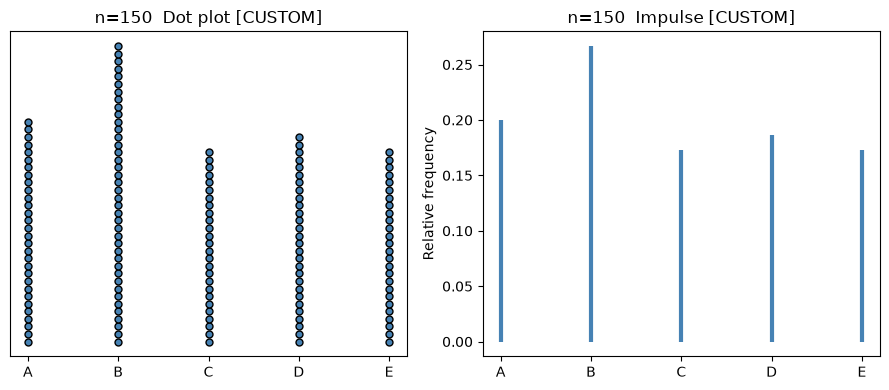

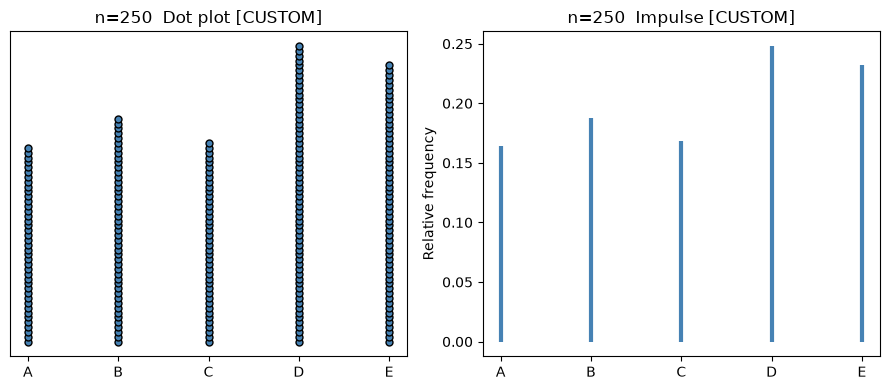

In [63]:
for n in N_SWEEP:
    labels = BoxModel(['A', 'B', 'C', 'D', 'E']).sim(n).results
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    categorical_dot_plot(axes[0], labels, title=f"n={n}  Dot plot [CUSTOM]")
    categorical_impulse_plot(axes[1], labels, title=f"n={n}  Impulse [CUSTOM]")
    fig.tight_layout()
    plt.show()

**Distinct-category sweep**, fixed n=100 (small enough that the dot plot panel
is still legible going in -- the n-sweep above already shows dot plots degenerate
into a solid blob well before n=3000, so testing category-count crowding *at*
n=3000 would confound the two effects). Unlike ordered numeric discrete data,
category labels have no natural order, so tick-label crowding may become a
problem at a *lower* category count than the numeric `n_unique_threshold` found
in section 1.

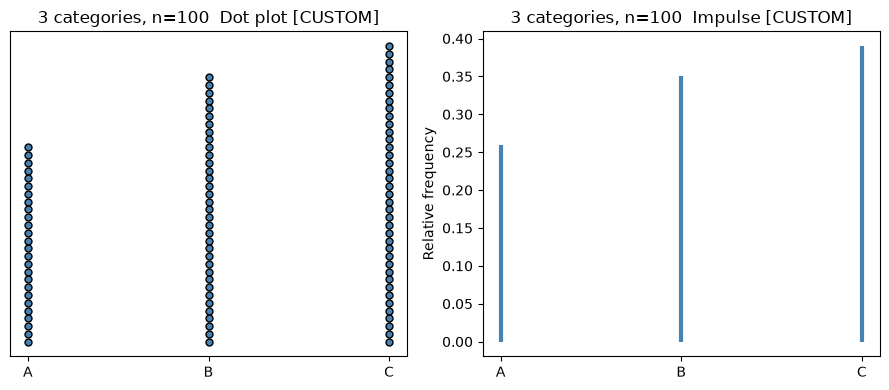

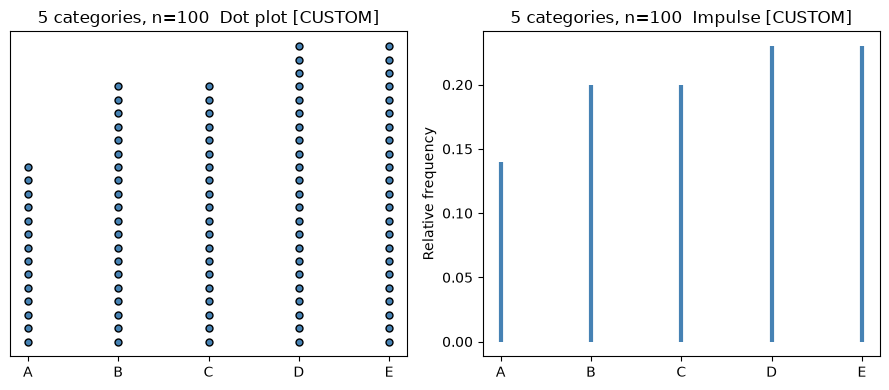

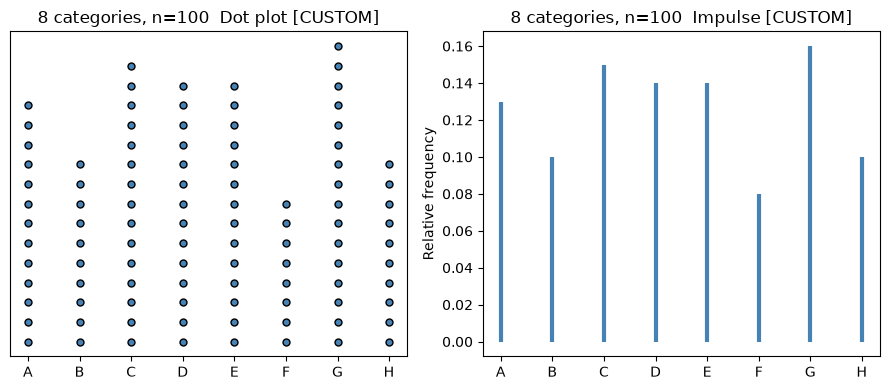

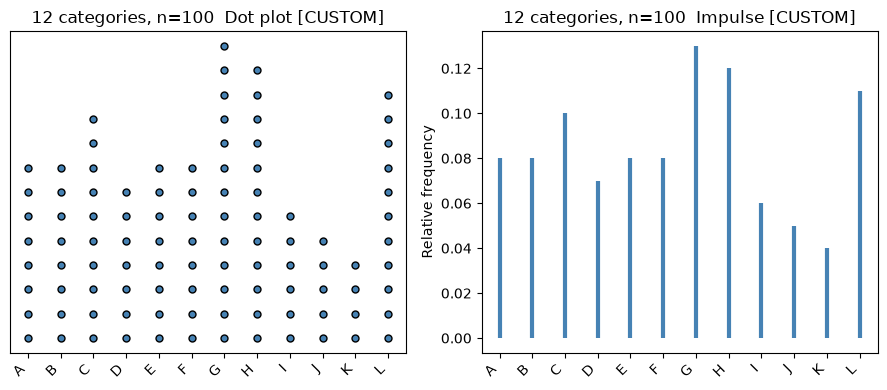

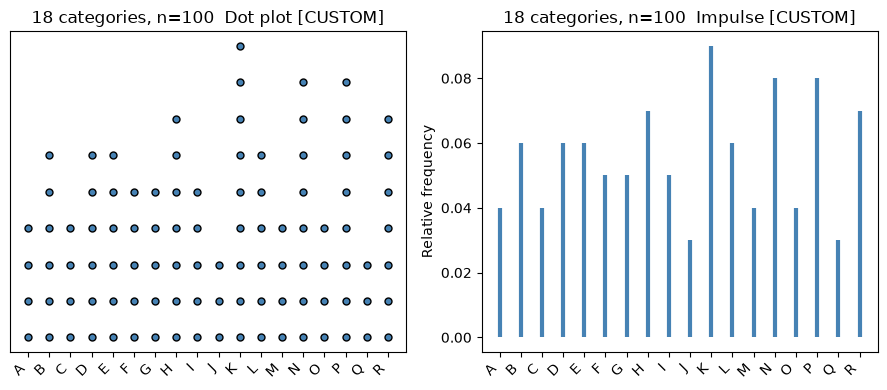

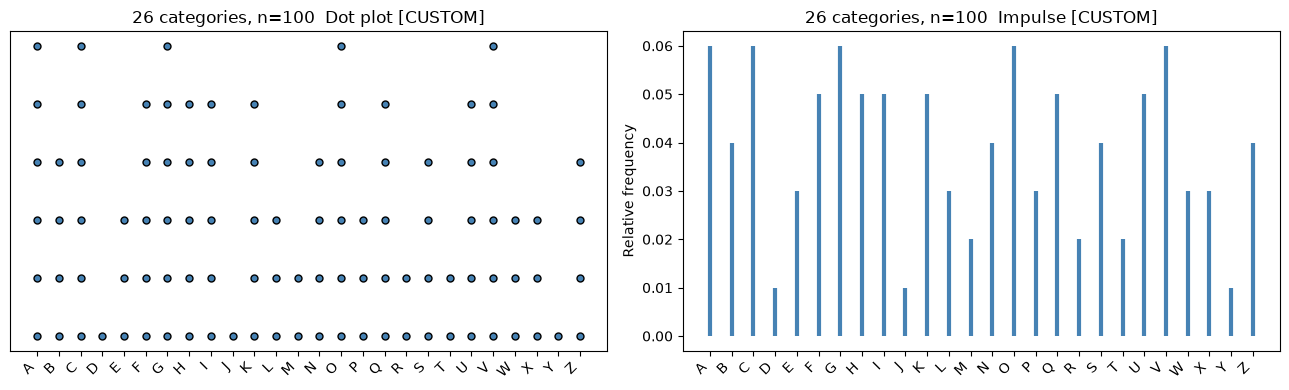

In [64]:
import string

CAT_COUNT_SWEEP = [3, 5, 8, 12, 18, 26]

for n_cats in CAT_COUNT_SWEEP:
    cats = list(string.ascii_uppercase[:n_cats])
    labels = BoxModel(cats).sim(100).results
    fig, axes = plt.subplots(1, 2, figsize=(max(9, 0.5 * n_cats), 4))
    categorical_dot_plot(axes[0], labels, title=f"{n_cats} categories, n=100  Dot plot [CUSTOM]")
    categorical_impulse_plot(axes[1], labels, title=f"{n_cats} categories, n=100  Impulse [CUSTOM]")
    fig.tight_layout()
    plt.show()

Separately, check whether **impulse** (the large-n default) also runs into
tick-label crowding as category count grows, independent of the dot-plot-specific
failure mode above -- fixed n=3000 this time, impulse only:

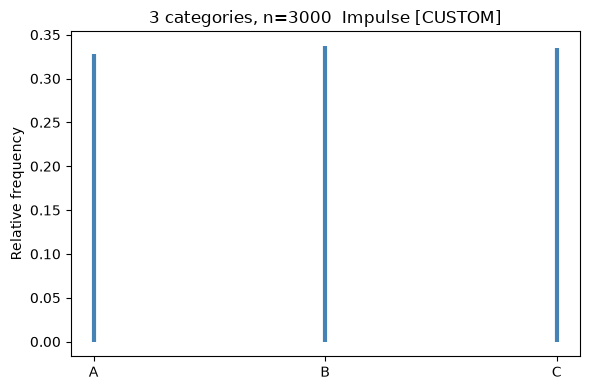

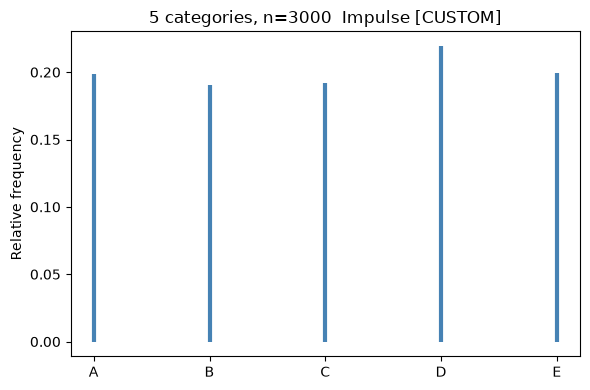

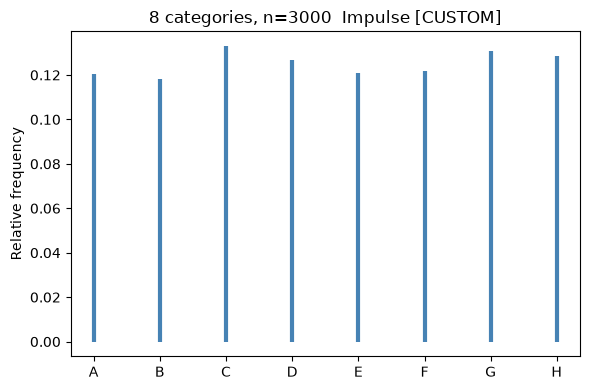

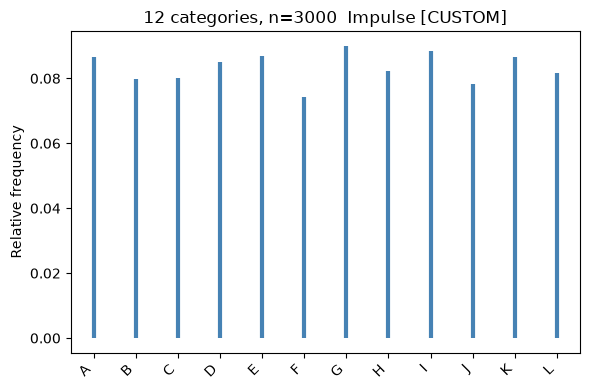

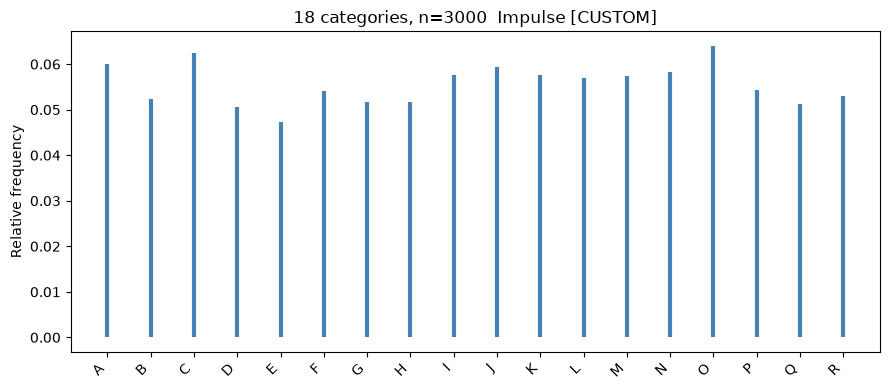

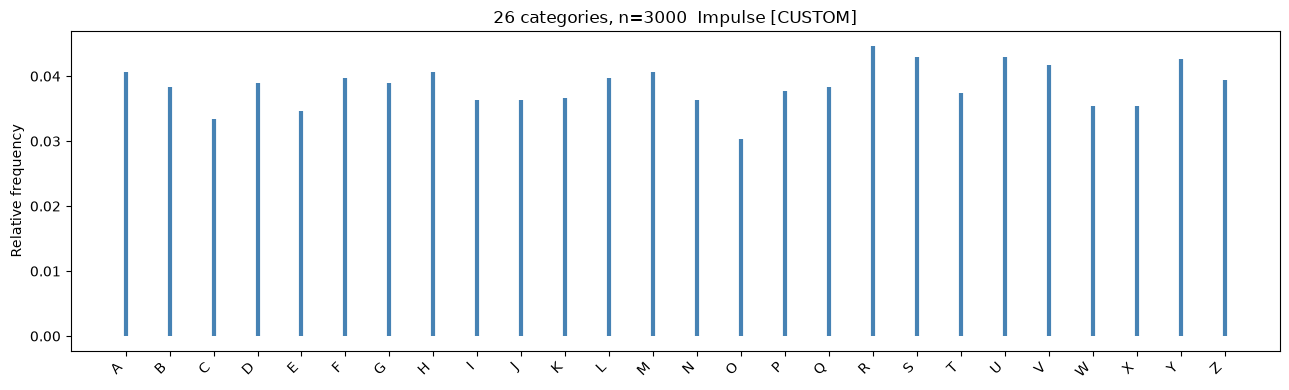

In [65]:
for n_cats in CAT_COUNT_SWEEP:
    cats = list(string.ascii_uppercase[:n_cats])
    labels = BoxModel(cats).sim(3000).results
    fig, ax = plt.subplots(figsize=(max(6, 0.5 * n_cats), 4))
    categorical_impulse_plot(ax, labels, title=f"{n_cats} categories, n=3000  Impulse [CUSTOM]")
    fig.tight_layout()
    plt.show()

_Notes -- categorical crossover n, and max readable category count:_

- Crossover n (dot plot -> impulse):
- Max readable number of categories (tick-label crowding, separate concern from `n_unique_threshold`):


---
## Overlay variants -- visual reference only (not swept for n cutoffs)

These address comparing 2+ groups on one plot via color, which is a different
concern from the small/large-n question above. One small-n and one large-n
mockup per category, for visual reference.

### Overlay, 1D discrete-ish: stacked dot plots (small n) / stacked impulse plots (large n), colored by group

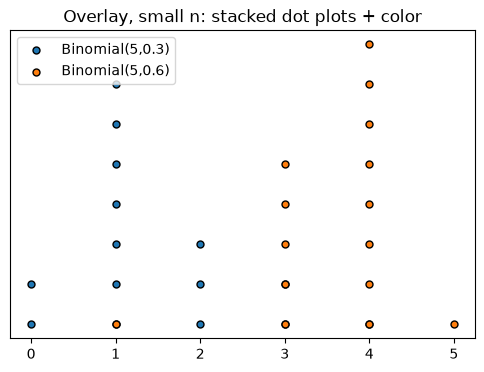

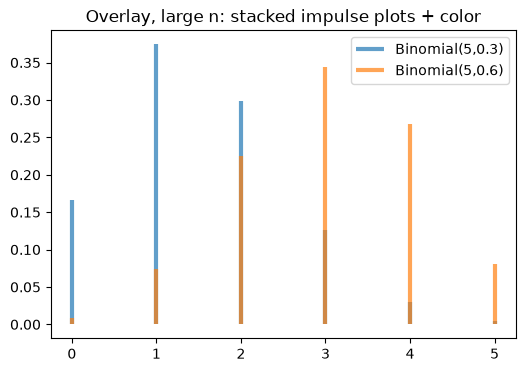

In [66]:
def overlay_dot_plot(ax, groups_dict):
    for color_i, (label, values) in enumerate(groups_dict.items()):
        counts = get_counts(values)
        color = plt.cm.tab10(color_i)
        for x, c in counts.items():
            ax.scatter([x] * c, range(1, c + 1), color=color, edgecolor='black', zorder=3, s=25, label=label if x == list(counts.keys())[0] else None)
    ax.legend()
    ax.set_yticks([])

def overlay_impulse_plot(ax, groups_dict):
    for color_i, (label, values) in enumerate(groups_dict.items()):
        counts = get_counts(values)
        color = plt.cm.tab10(color_i)
        xs = list(counts.keys())
        heights = [v / len(values) for v in counts.values()]
        ax.vlines(xs, 0, heights, color=color, linewidth=3, alpha=0.7, label=label)
    ax.legend()

sim_a = RV(Binomial(5, 0.3)).sim(15); sim_a._set_array()
sim_b = RV(Binomial(5, 0.6)).sim(15); sim_b._set_array()
fig, ax = plt.subplots(figsize=(6, 4))
overlay_dot_plot(ax, {"Binomial(5,0.3)": sim_a.array, "Binomial(5,0.6)": sim_b.array})
ax.set_title("Overlay, small n: stacked dot plots + color")
plt.show()

sim_a = RV(Binomial(5, 0.3)).sim(3000); sim_a._set_array()
sim_b = RV(Binomial(5, 0.6)).sim(3000); sim_b._set_array()
fig, ax = plt.subplots(figsize=(6, 4))
overlay_impulse_plot(ax, {"Binomial(5,0.3)": sim_a.array, "Binomial(5,0.6)": sim_b.array})
ax.set_title("Overlay, large n: stacked impulse plots + color")
plt.show()

### Overlay, 1D continuous-ish: stacked strip plots with a vertical gap between groups (small n) / stacked histograms + color (large n)

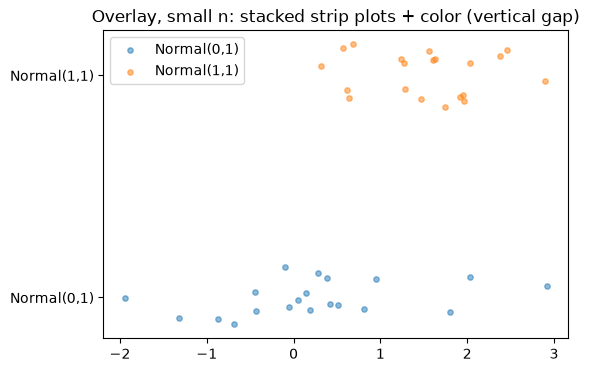

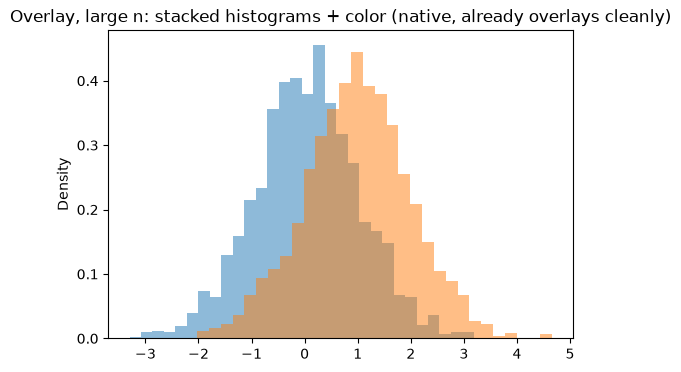

In [67]:
def overlay_strip_plot(ax, groups_dict, gap=1.0):
    for i, (label, values) in enumerate(groups_dict.items()):
        y = i * gap + np.random.uniform(-0.15, 0.15, size=len(values))
        ax.scatter(values, y, alpha=0.5, color=plt.cm.tab10(i), s=15, label=label)
    ax.set_yticks([i * gap for i in range(len(groups_dict))])
    ax.set_yticklabels(list(groups_dict.keys()))
    ax.legend()

sim_a = RV(Normal()).sim(20); sim_a._set_array()
sim_b = RV(Normal(1, 1)).sim(20); sim_b._set_array()
fig, ax = plt.subplots(figsize=(6, 4))
overlay_strip_plot(ax, {"Normal(0,1)": sim_a.array, "Normal(1,1)": sim_b.array})
ax.set_title("Overlay, small n: stacked strip plots + color (vertical gap)")
plt.show()

sim_a = RV(Normal()).sim(2000)
sim_b = RV(Normal(1, 1)).sim(2000)
fig, ax = plt.subplots(figsize=(6, 4))
plt.sca(ax)
sim_a.plot(type='hist', alpha=0.5)
sim_b.plot(type='hist', alpha=0.5)
ax.set_title("Overlay, large n: stacked histograms + color (native, already overlays cleanly)")
plt.show()

### Overlay, 2D discrete x discrete / continuous x continuous: scatter with jitter + color (both small and large n) -- heatmaps can't overlay, so the large-n candidate is side-by-side heatmaps instead of a single overlaid plot

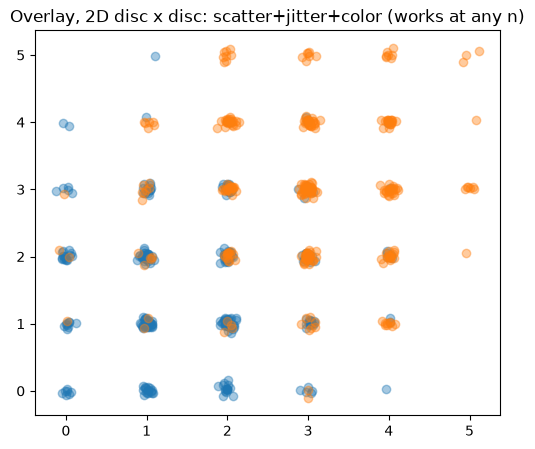

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\3631406335.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


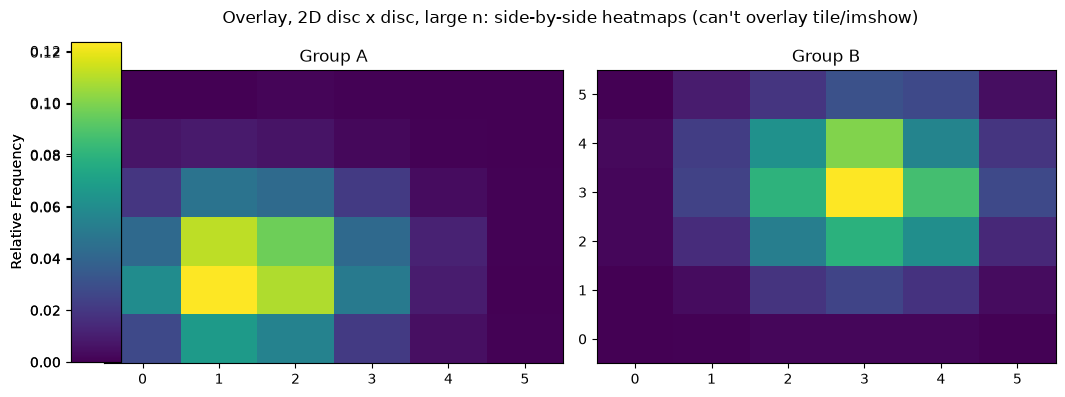

In [68]:
sim_a = RV(Binomial(5, 0.3) * Binomial(5, 0.3)).sim(300)
sim_b = RV(Binomial(5, 0.6) * Binomial(5, 0.6)).sim(300)
fig, ax = plt.subplots(figsize=(6, 5))
plt.sca(ax)
sim_a.plot(type='scatter', jitter=True, alpha=0.4)
sim_b.plot(type='scatter', jitter=True, alpha=0.4)
ax.set_title("Overlay, 2D disc x disc: scatter+jitter+color (works at any n)")
plt.show()

sim_a = RV(Binomial(5, 0.3) * Binomial(5, 0.3)).sim(3000)
sim_b = RV(Binomial(5, 0.6) * Binomial(5, 0.6)).sim(3000)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plt.sca(axes[0]); sim_a.plot(type='tile'); axes[0].set_title("Group A")
plt.sca(axes[1]); sim_b.plot(type='tile'); axes[1].set_title("Group B")
fig.suptitle("Overlay, 2D disc x disc, large n: side-by-side heatmaps (can't overlay tile/imshow)")
fig.tight_layout()
plt.show()

### Overlay, 2D discrete x continuous: stacked segmented strip plot + color (small n) / stacked violin plots + color, with a gap between groups (large n)

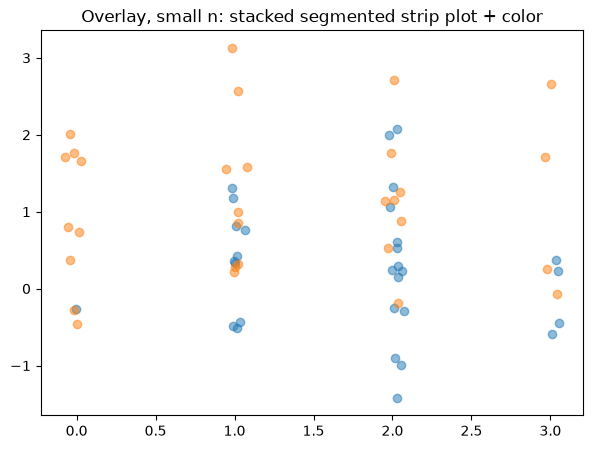

C:\Users\agw07\AppData\Local\Temp\ipykernel_29416\2356406585.py:49: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.violinplot(groups, positions=positions, showmedians=True, vert=vert)


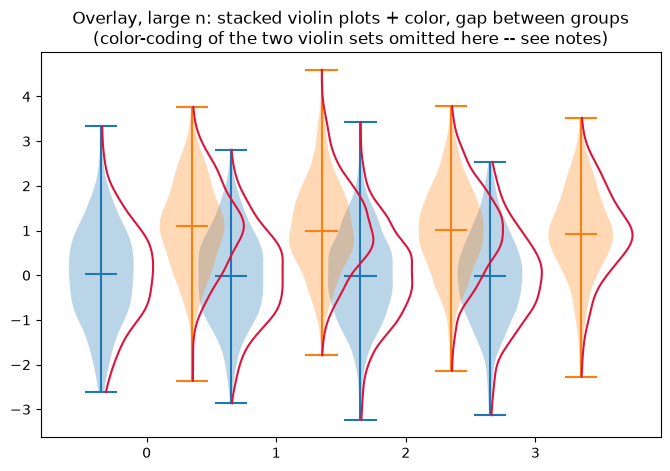

In [69]:
sim_a = RV(Binomial(3, 0.5) * Normal()).sim(30)
sim_b = RV(Binomial(3, 0.5) * Normal(1, 1)).sim(30)
fig, ax = plt.subplots(figsize=(7, 5))
plt.sca(ax)
sim_a.plot(type='scatter', jitter=True, alpha=0.5)
sim_b.plot(type='scatter', jitter=True, alpha=0.5)
ax.set_title("Overlay, small n: stacked segmented strip plot + color")
plt.show()

sim_a = RV(Binomial(3, 0.5) * Normal()).sim(2000); sim_a._set_array()
sim_b = RV(Binomial(3, 0.5) * Normal(1, 1)).sim(2000); sim_b._set_array()
xa, ya = sim_a.array[:, 0], sim_a.array[:, 1]
xb, yb = sim_b.array[:, 0], sim_b.array[:, 1]
gap = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
groups_a = {xv - gap: ya[xa == xv] for xv in sorted(set(xa))}
groups_b = {xv + gap: yb[xb == xv] for xv in sorted(set(xb))}
violin_plus_density(ax, groups_a, vert=True)
violin_plus_density(ax, groups_b, vert=True)
ax.set_xticks(sorted(set(xa)))
ax.set_title("Overlay, large n: stacked violin plots + color, gap between groups\n(color-coding of the two violin sets omitted here -- see notes)")
plt.show()

_Notes -- overlay mockups:_

- The large-n discrete x discrete "side-by-side heatmaps" mockup above needs a
  shared color scale between panels to be a fair comparison -- worth fixing if
  this becomes the real implementation.
- The large-n discrete x continuous violin overlay above doesn't yet color-code
  the two groups distinctly (both violins render in matplotlib's default color) --
  a real implementation would need `violin_plus_density` to accept a color
  argument.
- 